In [1]:
import random
import numpy as np
from tqdm import tqdm
import pickle

import torch
import torch.nn.functional as F

import trimesh
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


import sys
from pathlib import Path
abs_path = str(Path.cwd().parents[0].absolute())
if not abs_path in sys.path:
    sys.path+=[abs_path]
print(sys.path)

%load_ext autoreload
%autoreload 2
from utils.exp_utils import *
from utils.remesh_utils import ICT_face_model, compute_MVC, apply_MVC_weights_batch
#from utils.exp_utils import Model_mk1, Model_mk3_1, Model_mk2_1, Model_mk3_3

try:
    from matplotrender import *
except:
    !pip install git+https://github.com/chacorp/matplotrender.git
    from matplotrender import *


['/opt/conda/lib/python310.zip', '/opt/conda/lib/python3.10', '/opt/conda/lib/python3.10/lib-dynload', '', '/opt/conda/lib/python3.10/site-packages', '/workspace/pytorch3d', '/source/sihun/NeuralFacialAnimation']
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(seed)
    random.seed(seed)
set_seed(42)

# Normalize vertices to homogeneous coordinates
def normalize_homogeneous(V):
    return np.concatenate([V, np.ones((V.shape[0], 1))], axis=1)

def vis_mesh(verts, faces, SIZE=4):
    V = normalize_homogeneous(verts) 
    print(verts.min(0), verts.max(0))
    
    model = yrotate(0)
    view  = translate(0, 0, -3.5)
    proj  = perspective(55, 1, 1, 100)
    MVP   = proj @ view @ model
    V = V @ MVP.T
    V /= V[:, 3].reshape(-1, 1)

    VF = V[faces]
    T = VF[:, :, :2]
    Z = -VF[:, :, 2].mean(axis=1)
    Z = (Z - Z.min()) / (Z.max() - Z.min())
    C = plt.get_cmap("magma")(Z)
    I = np.argsort(Z)

    T, C = T[I, :], C[I, :]
    fig = plt.figure(figsize=(SIZE, SIZE))
    ax = fig.add_axes([0, 0, 1, 1], xlim=[-1, 1], ylim=[-1, 1], aspect=1, frameon=False)
    collection = PolyCollection(T, closed=True, linewidth=0.1, facecolor=C, edgecolor="black")
    ax.add_collection(collection)
    plt.show()

def vis_simple(v_list, f_list, SIZE=2,mesh_scale = .8):
    # xyz Euler angle to rotate the mesh
    rot_list=[ [10,0,0] ]*len(v_list)

    plot_mesh_gouraud(v_list, f_list, mesh_scale=mesh_scale,
                     # is_diff=True, diff_base=v_list[0], #diff_revert=True,
                     rot_list=rot_list, size=SIZE, mode='shade')



def draw_mesh_and_key_v(template_v_th, key_v, faces):
    mesh_v = template_v_th.detach().cpu().numpy()
    points = key_v.detach().cpu().numpy()

    fig = plt.figure(figsize=(5, 7))
    ax = fig.add_subplot(111, projection='3d')


    ax.plot_trisurf(mesh_v[:, 0], mesh_v[:, 1], mesh_v[:, 2],
                    triangles=faces, alpha=0.5, color='lightblue', linewidth=0.1)

    ax.scatter(points[:, 0], points[:, 1], points[:, 2], color='r', s=1)
    ax.view_init(elev=90, azim=-90)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.tight_layout()
    plt.show()

def vis_mesh_and_pointcloud(verts, faces, points=None, SIZE=5, point_color='r'):
    """
    Static 3D visualization of a mesh (verts, faces) and optional point cloud using matplotlib.
    - verts: (N, 3) mesh vertices
    - faces: (F, 3) mesh face indices
    - points: (M, 3) optional point cloud to overlay
    """

    # Normalize to homogeneous coordinates
    V_homo = np.concatenate([verts, np.ones((verts.shape[0], 1))], axis=1)

    # MVP transform
    model = yrotate(0)
    view  = translate(0, 0, -3.5)
    proj  = perspective(55, 1, 1, 100)
    MVP   = proj @ view @ model

    V_proj = (V_homo @ MVP.T)
    V_proj /= V_proj[:, 3:4]

    # Prepare triangles and depth
    VF = V_proj[faces]
    T = VF[:, :, :2]         # 2D projected triangles
    Z = -VF[:, :, 2].mean(axis=1)
    Z = (Z - Z.min()) / (Z.max() - Z.min())
    C = plt.get_cmap("magma")(Z)
    I = np.argsort(Z)

    # Sort by depth
    T, C = T[I, :], C[I, :]

    # Draw mesh
    fig = plt.figure(figsize=(SIZE, SIZE))
    ax = fig.add_axes([0, 0, 1, 1], xlim=[-1, 1], ylim=[-1, 1], aspect=1, frameon=False)
    collection = PolyCollection(T, closed=True, linewidth=0.1, facecolor=C, edgecolor="black")
    ax.add_collection(collection)

    # Draw point cloud if given
    if points is not None:
        # Project points
        P = np.concatenate([points, np.ones((points.shape[0], 1))], axis=1)
        P = P @ MVP.T
        P /= P[:, 3:4]
        ax.scatter(P[:, 0], P[:, 1], s=5, color=point_color, zorder=10)

    plt.show()
    
def draw_key_weight(data):
    data = data.detach().cpu().numpy()
    #normed = (data - data.min(1,keepdims=True)) / (data.max(1,keepdims=True) - data.min(1,keepdims=True))
    #print(normed.min(),normed.max())
    
    plt.figure(figsize=(5, 6))  # set figure size to 5x5 inches
    plt.imshow(data, aspect='auto', cmap='viridis', vmin=data.min(), vmax=data.max())  # aspect='auto' to stretch
    plt.colorbar(label='Value')  # optional colorbar
    plt.xlabel("Features (8)")
    plt.ylabel("Samples (512)")
    plt.title("Array Visualization (512 x 8)")
    plt.show()

In [3]:
with open("/data/sihun/pca/MF/mf_templates.pkl",'rb') as f:
    mf_templates = pickle.load(f)

pca_holder1 = PCA_holder(
    '/data/sihun/pca/MF/ROM/val/m--20190529--1300--002421669--GHS_pca.npz'
)
pca_holder2 = PCA_holder(
    '/data/sihun/pca/MF/ROM/test/m--20190828--1318--002645310--GHS_pca.npz'
)
pca_holder3 = PCA_holder(
    '/data/sihun/pca/MF/ROM/train/m--20171024--0000--002757580--GHS_pca.npz'
)


pca_holder4 = PCA_holder(
    '/data/sihun/pca/MF/ROM/train/m--20181017--0000--002914589--GHS_pca.npz'
)


pca_holder = pca_holder1
template_v = pca_holder.mean_.reshape(-1, 3)
components_ = pca_holder.components_
n_components_ = pca_holder.n_components_
faces = mf_templates['face']
print(components_.shape, n_components_)

(100, 15669) 100


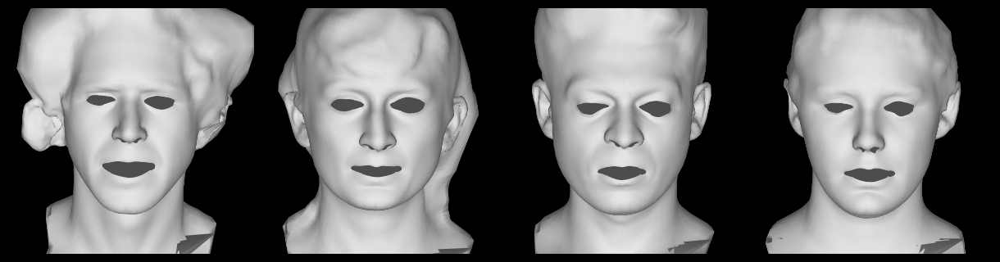

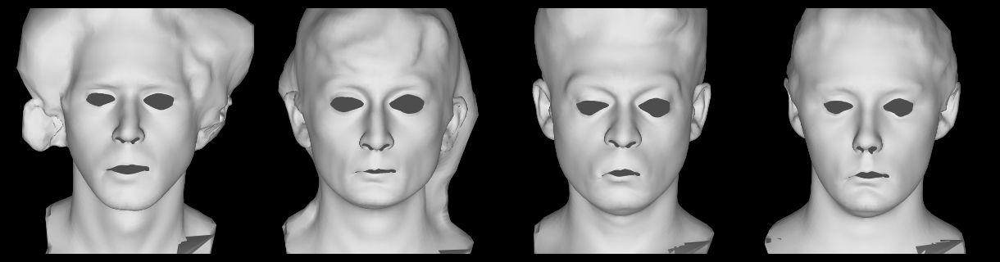

In [4]:
z = np.random.randn(n_components_) * np.sqrt(pca_holder.explained_variance_)
deformed_v = pca_holder.inverse_transform(z)
delta_v = deformed_v - pca_holder.mean_.reshape(-1, 3)

v_list=[
    pca_holder1.mean_.reshape(-1, 3),
    pca_holder2.mean_.reshape(-1, 3),
    pca_holder3.mean_.reshape(-1, 3),
    pca_holder4.mean_.reshape(-1, 3),
]

v_list2=[
    deformed_v,
    pca_holder2.mean_.reshape(-1, 3)+delta_v,
    pca_holder3.mean_.reshape(-1, 3)+delta_v,
    pca_holder4.mean_.reshape(-1, 3)+delta_v,
]
vis_simple(v_list, [faces]*len(v_list),SIZE=3)
vis_simple(v_list2, [faces]*len(v_list),SIZE=3)

In [5]:
def evaluation_mse5(
        key_d_model,
        key_weight_model,
        exp_z_model,
        recon_model,
        pca_holder, 
        B=8, M=128, num_sample=1000
    ):
    """
    Returns:
        evaluated results (recon_template, recon_deformed)
    """
    print(f'batch: {B}, num_sample: {num_sample}, iteration: {num_sample//B}')
    num_sample = num_sample//B
    

    losss = 0
    
    key_d_model.eval()
    key_weight_model.eval()
    exp_z_model.eval()
    recon_model.eval()

    t_v_th = torch.tensor(pca_holder.mean_.reshape(-1,3)).float().to(device)
    t_v_B_th = t_v_th[None].repeat(B,1,1)
    
    set_seed(42)
    for i in tqdm(range(num_sample)):
        z = np.random.randn(B, pca_holder.n_components_) * np.sqrt(pca_holder.explained_variance_)
        deformed_v = pca_holder.inverse_transform(z).reshape(B,-1,3)
        #print(deformed_v.shape)
        z_th = torch.tensor(z).float().to(device)
        deformed_v_th = torch.tensor(deformed_v).float().to(device)

        with torch.no_grad():
            
            key_weight = key_weight_model(t_v_B_th) # (B, N, M)
            
            exp_z = exp_z_model(deformed_v_th) # (B, 1, L)
            
            key_d = key_d_model(exp_z).reshape(B, M, 3)
            
            recon_delta_v_th = recon_model(exp_z)
            recon_deformed_v_th = recon_delta_v_th.reshape(B, N, 3) + t_v_B_th
            
            delta_v_th = torch.einsum('bnc,bci->bni',key_weight, key_d)
            recon_deformed = delta_v_th + t_v_B_th
            
            loss = F.mse_loss(deformed_v_th, recon_deformed)
        losss +=loss.item()
        #print(loss.item())
    losss = losss / num_sample
    print(f"{losss:5e}")
    return recon_deformed, recon_deformed_v_th, deformed_v_th, key_d
    
def evaluation_mse5_1(
        key_d_model,
        key_weight_model,
        shape_model,
        exp_z_model,
        recon_model,
        pca_holder, 
        B=8, M=128, num_sample=1000
    ):
    """
    Returns:
        evaluated results (recon_template, recon_deformed)
    """
    print(f'batch: {B}, num_sample: {num_sample}, iteration: {num_sample//B}')
    num_sample = num_sample//B
    
    losss = 0
    
    key_d_model.eval()
    key_weight_model.eval()
    shape_model.eval()
    exp_z_model.eval()
    recon_model.eval()

    t_v_th = torch.tensor(pca_holder.mean_.reshape(-1,3)).float().to(device)
    t_v_B_th = t_v_th[None].repeat(B,1,1)
    
    set_seed(42)
    for i in tqdm(range(num_sample)):
        z = np.random.randn(B, pca_holder.n_components_) * np.sqrt(pca_holder.explained_variance_)
        deformed_v = pca_holder.inverse_transform(z).reshape(B,-1,3)
        #print(deformed_v.shape)
        z_th = torch.tensor(z).float().to(device)
        deformed_v_th = torch.tensor(deformed_v).float().to(device)

        with torch.no_grad():
            z_ID_B = shape_model(t_v_B_th) # (B, 1, L)
            
            exp_z = exp_z_model(deformed_v_th, z_ID_B) # (B, 1, L)
            
            key_d = key_d_model(exp_z, z_ID_B)
            key_d = key_d.reshape(B, M, 3)
            
            recon_deformed_v_th = recon_model(exp_z, z_ID_B)
            recon_deformed_v_th = recon_deformed_v_th.reshape(B, N, 3)
                        
            key_weight = key_weight_model(t_v_B_th) # (B, N, M)
            
            delta_v_th = torch.einsum('bnc,bci->bni',key_weight, key_d)
            recon_deformed = delta_v_th + t_v_B_th
            
            loss = F.mse_loss(deformed_v_th, recon_deformed)
        losss +=loss.item()
        #print(loss.item())
    losss = losss / num_sample
    print(f"{losss:5e}")
    return recon_deformed, recon_deformed_v_th, deformed_v_th, key_d

# test ?

000, 3.471521e-01:   0%|          | 0/20000 [00:00<?, ?it/s]

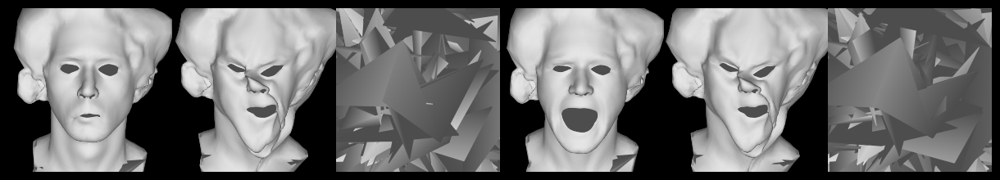

1000, 2.721925e-03:   5%|▍         | 995/20000 [00:22<05:45, 55.06it/s]

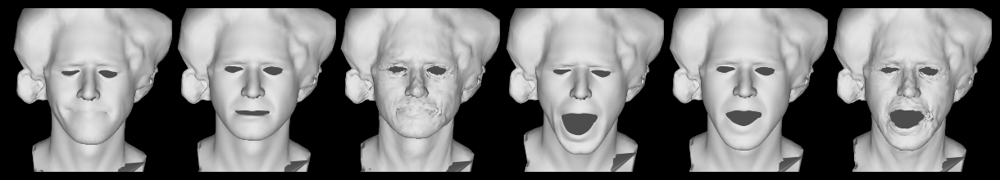

2000, 1.814131e-03:  10%|▉         | 1995/20000 [00:43<05:30, 54.41it/s]

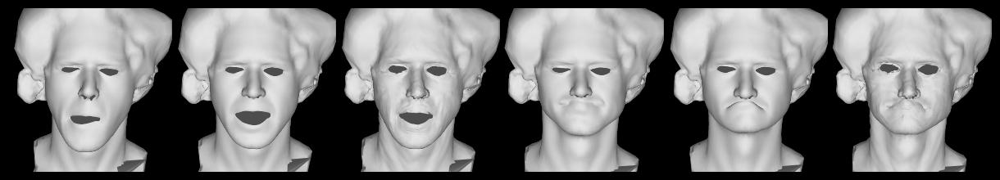

3000, 1.864784e-03:  15%|█▍        | 2997/20000 [01:04<06:24, 44.24it/s]

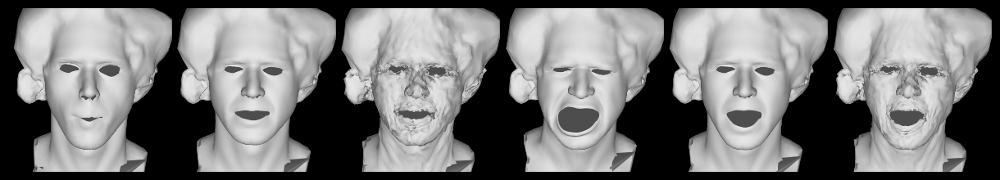

4000, 1.377155e-03:  20%|█▉        | 3999/20000 [01:27<07:30, 35.52it/s]

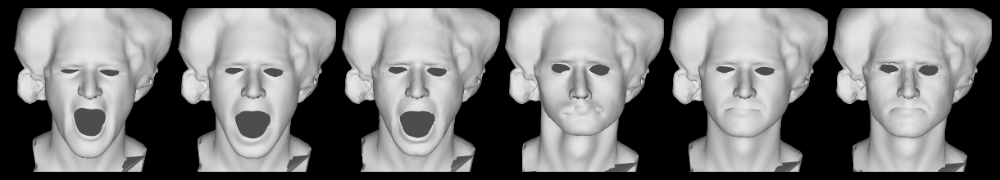

5000, 1.011068e-03:  25%|██▍       | 4997/20000 [01:50<04:26, 56.29it/s]

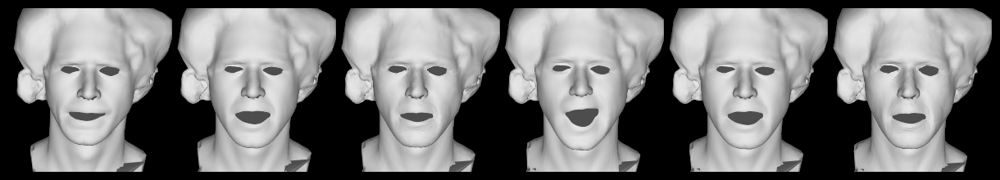

6000, 1.320818e-03:  30%|██▉       | 5998/20000 [02:13<04:53, 47.77it/s]

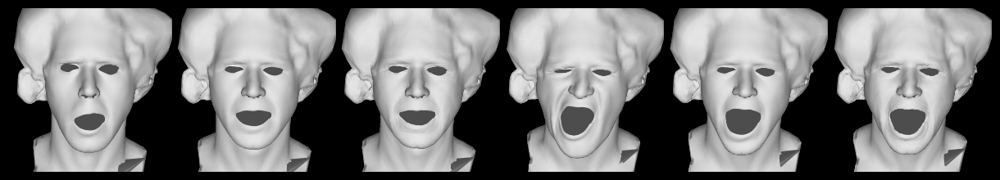

7000, 1.161816e-03:  35%|███▍      | 6995/20000 [02:36<03:50, 56.38it/s]

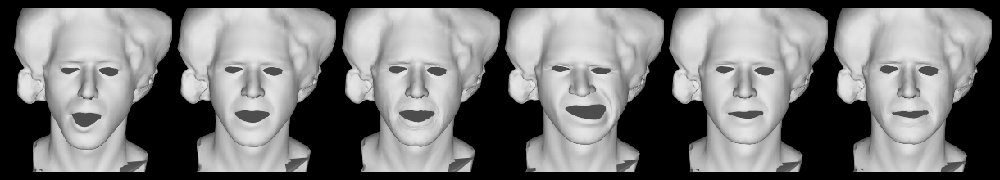

8000, 7.298054e-04:  40%|███▉      | 7995/20000 [02:59<03:51, 51.80it/s]

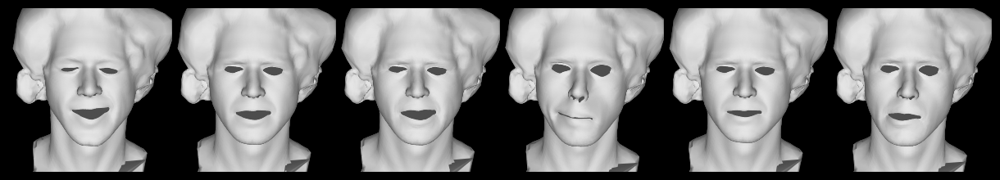

9000, 9.522553e-04:  45%|████▍     | 8997/20000 [03:21<03:45, 48.73it/s]

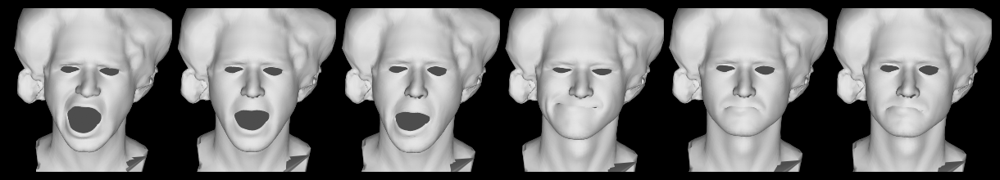

10000, 7.654395e-04:  50%|████▉     | 9998/20000 [03:42<03:03, 54.49it/s]

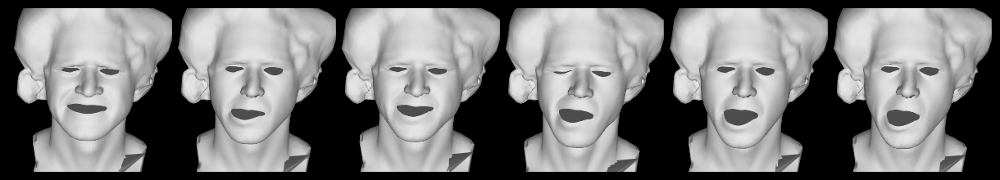

11000, 5.422527e-04:  55%|█████▍    | 10999/20000 [04:05<03:01, 49.65it/s]

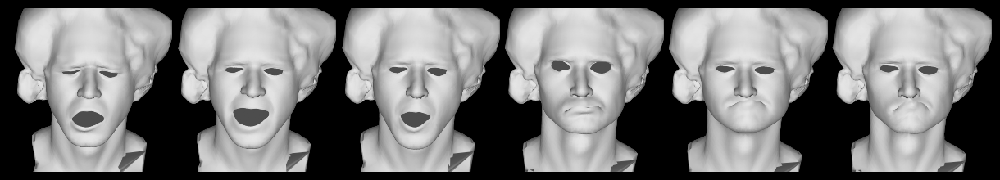

12000, 8.354201e-04:  60%|█████▉    | 11997/20000 [04:28<03:35, 37.22it/s]

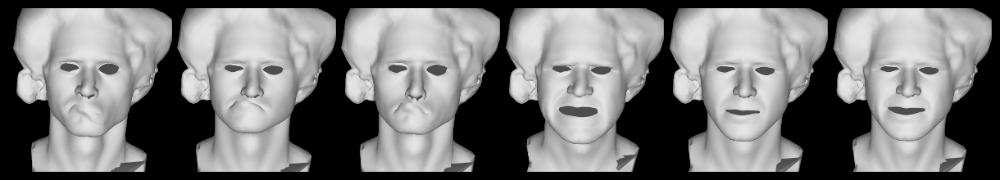

13000, 6.924077e-04:  65%|██████▌   | 13000/20000 [04:52<02:58, 39.24it/s]

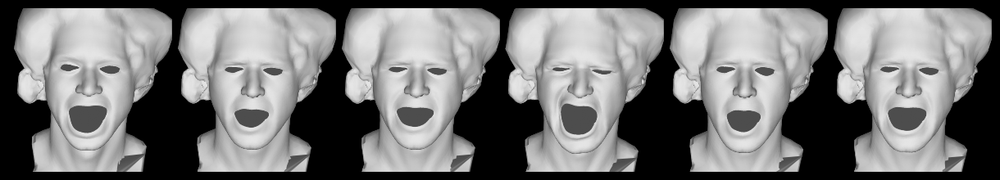

14000, 5.052395e-04:  70%|███████   | 14000/20000 [05:15<01:52, 53.44it/s]

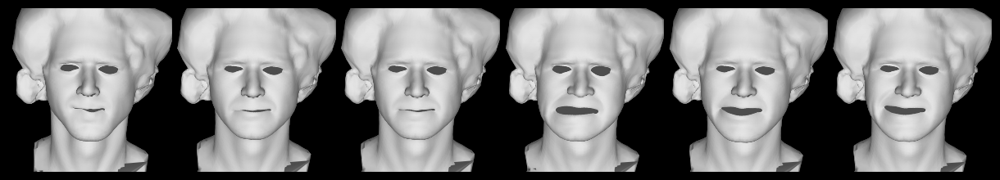

15000, 5.398118e-04:  75%|███████▍  | 14999/20000 [05:37<01:39, 50.51it/s]

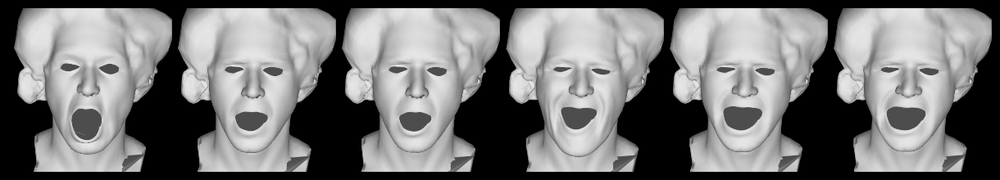

16000, 3.359882e-04:  80%|███████▉  | 15995/20000 [05:59<01:18, 51.32it/s]

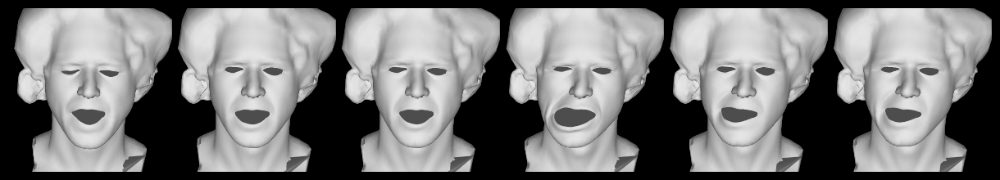

17000, 6.037070e-04:  85%|████████▍ | 16998/20000 [06:19<00:59, 50.87it/s]

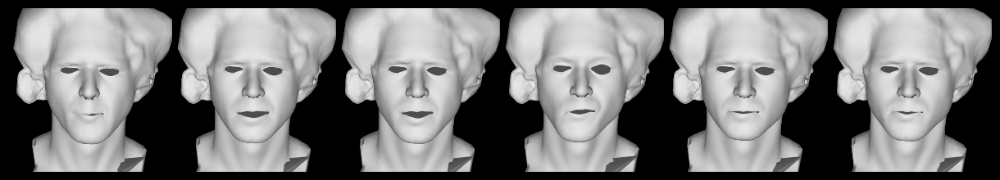

18000, 4.186899e-04:  90%|█████████ | 18000/20000 [06:44<00:42, 47.04it/s]

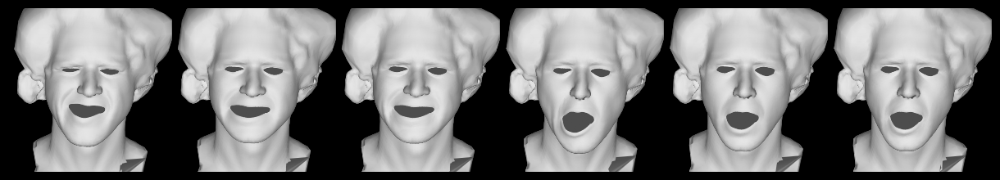

19000, 4.098906e-04:  95%|█████████▍| 18998/20000 [07:05<00:27, 37.10it/s]

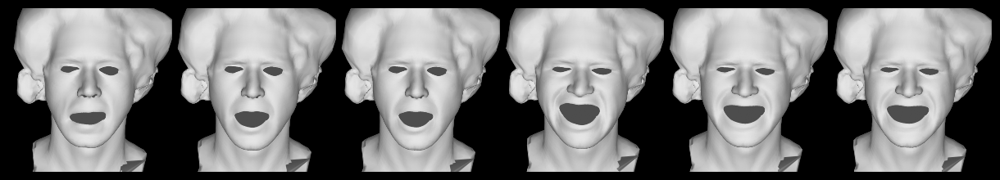

19999, 5.060473e-04: 100%|██████████| 20000/20000 [07:28<00:00, 44.60it/s]


In [22]:
from utils.exp_utils import Model, Model_mk2_1

N = template_v.shape[0]
M = 128
device = 'cuda:0'
max_influences=16
B = 8
HB = B//2
tau=0.01
L=256

def get_rand_pca_data():
    rand_number = np.random.rand()
    mode=0
    if rand_number < 0.3:
        pca1,pca2 = pca_holder1, pca_holder2
        mode=1
    elif rand_number >= 0.3 and rand_number < 0.6:
        pca1,pca2 = pca_holder2, pca_holder3
        mode=2
    else:
        pca1,pca2 = pca_holder3, pca_holder1
        mode=3
    
    z1 = np.random.randn(HB, pca1.n_components_) * np.sqrt(pca1.explained_variance_) * 1.5
    z = np.concatenate((z1,z1),axis=0)
    z_th = torch.tensor(z).float().to(device)
    
    delta_v = np.einsum('bc,cnk->bnk', z, pca1.components_.reshape(pca1.n_components_,-1,3))
    # delta_v_th = torch.tensor(delta_v).float().to(device)

    _v = np.concatenate((
        pca1.mean_.reshape(1, -1, 3).repeat(HB,0),
        pca2.mean_.reshape(1, -1, 3).repeat(HB,0)
    ), axis=0)
    deformed_v = delta_v + _v
    deformed_v_th = torch.tensor(deformed_v).float().to(device)
    
    return z_th, deformed_v_th, mode
    

def get_one_pca_data():
    mode=1
    pca1,pca2 = pca_holder1, pca_holder2
    
    z = np.random.randn(B, pca1.n_components_) * np.sqrt(pca1.explained_variance_) * 1.5
    z_th = torch.tensor(z).float().to(device)
    
    delta_v = np.einsum('bc,cnk->bnk', z, pca1.components_.reshape(pca1.n_components_,-1,3))
    
    _v = pca1.mean_.reshape(1, -1, 3).repeat(B,0)
    deformed_v = delta_v + _v
    deformed_v_th = torch.tensor(deformed_v).float().to(device)
    
    return z_th, deformed_v_th, mode
    
template_v1 = pca_holder1.mean_.reshape(-1, 3)
template_v2 = pca_holder2.mean_.reshape(-1, 3)
template_v3 = pca_holder3.mean_.reshape(-1, 3)

lap1 = igl.cotmatrix(template_v1, faces)
lap1_th = torch.tensor(lap1.todense()).float().to_sparse().to(device)

lap2 = igl.cotmatrix(template_v2, faces)
lap2_th = torch.tensor(lap2.todense()).float().to_sparse().to(device)

lap3 = igl.cotmatrix(template_v3, faces)
lap3_th = torch.tensor(lap3.todense()).float().to_sparse().to(device)

template_v1_th = torch.tensor(template_v1).float().to(device)
template_v2_th = torch.tensor(template_v2).float().to(device)
template_v3_th = torch.tensor(template_v3).float().to(device)

template_diff1_th = lap1_th @ template_v1_th
template_diff2_th = lap2_th @ template_v2_th
template_diff3_th = lap3_th @ template_v3_th

# t_v12 = torch.cat([template_v1_th[None]]*HB+[template_v2_th[None]]*HB,dim=0)
# t_v23 = torch.cat([template_v2_th[None]]*HB+[template_v3_th[None]]*HB,dim=0)
# t_v31 = torch.cat([template_v3_th[None]]*HB+[template_v1_th[None]]*HB,dim=0)

#t_v11 = torch.cat([template_v1_th[None],template_v1_th[None]],dim=0)
t_v11 = template_v1_th[None].repeat(B,1,1)

t_v12 = torch.cat([template_v1_th[None],template_v2_th[None]],dim=0)
t_v23 = torch.cat([template_v2_th[None],template_v3_th[None]],dim=0)
t_v31 = torch.cat([template_v3_th[None],template_v1_th[None]],dim=0)

# t_diff12 = torch.cat([template_diff1_th[None],template_diff2_th[None]],dim=0)
# t_diff23 = torch.cat([template_diff2_th[None],template_diff3_th[None]],dim=0)
# t_diff13 = torch.cat([template_diff1_th[None],template_diff3_th[None]],dim=0)

set_seed(42)

key_weight_model = Model(3, M, use_softmax=True).to(device)

#exp_z_model = Model_mk2_1(3, style_dim=L, out_dim=L, use_style=True, out_type='global').to(device)
exp_z_model = Model(3, L, out_type='global').to(device)

# shape_model = Model(3, L, out_type='global').to(device)

key_d_model = Model(L, M*3, out_type='global').to(device)
# key_d_model = Model_mk2_1(L, style_dim=L, out_dim=M*3, use_style=True, out_type='global').to(device)

recon_model = Model(L, N*3, out_type='global').to(device)
# recon_model = Model_mk2_1(L, style_dim=L, out_dim=N*3, use_style=True, out_type='global').to(device)

zero_w = torch.zeros(N,M).to(device)


optimizer = torch.optim.AdamW([
    *key_d_model.parameters(),
    *key_weight_model.parameters(),
    # *shape_model.parameters(),
    *exp_z_model.parameters(),
    *recon_model.parameters(),
], lr=1e-3, betas=(0.9, 0.999))
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.9)

key_d_model.train()
key_weight_model.train()
# shape_model.train()
exp_z_model.train()
recon_model.train()

pbar = tqdm(range(20_000))
for i in pbar:
    optimizer.zero_grad()
    
    ## data--------------- #
    #exp_z_th, deformed_v_th, mode = get_rand_pca_data()
    #if mode==1:
    #    t_v = t_v12
    #elif mode==2:
    #    t_v = t_v23
    #else:
    #    t_v = t_v31
    exp_z_th, deformed_v_th, mode = get_one_pca_data()
    t_v = t_v11
    ## ------------------- #
    
    # z_ID_B = shape_model(t_v) # (B, 1, L)
    # z_ID_B = torch.cat([
    #     z_ID[0,None].repeat(HB,1,1),
    #     z_ID[1,None].repeat(HB,1,1),
    # ],dim=0)
    
    key_weight = key_weight_model(t_v) # (B, N, M)
    
    #exp_z = exp_z_model(deformed_v_th, z_ID_B) # (B, 1, L)
    exp_z = exp_z_model(deformed_v_th) # (B, 1, L)
    
    key_d = key_d_model(exp_z)
    # key_d = key_d_model(exp_z, z_ID_B)
    key_d = key_d.reshape(B, M, 3)
    
    #recon_deformed_v_th = recon_model(exp_z, z_ID_B)
    recon_delta_v_th = recon_model(exp_z)
    recon_deformed_v_th = recon_delta_v_th.reshape(B, N, 3) + t_v
    

    # delta_v1_th = torch.einsum('nc,bci->bni',key_weight[0], key_d[:HB])
    # delta_v2_th = torch.einsum('nc,bci->bni',key_weight[1], key_d[HB:])
    # recon_deformed = torch.cat([
    #     delta_v1_th+t_v[0,None],
    #     delta_v2_th+t_v[1,None],
    # ],dim=0)
    
    delta_v_th = torch.einsum('bnc,bci->bni',key_weight,key_d)
    recon_deformed = delta_v_th+t_v
    
    loss = 0
    # loss = F.mse_loss(template_v_th, recon_template)
    # loss = F.mse_loss(exp_z[:HB], exp_z[HB:])
    loss += F.mse_loss(deformed_v_th, recon_deformed)
    loss += F.mse_loss(deformed_v_th, recon_deformed_v_th)
    
    # make it harmonic
    #loss += F.mse_loss(zero_w, lap_th @ key_weight) #* 0.5
    # loss += F.mse_loss(
    #     lap_th @ deformed_v_th.permute(1,0,2).reshape(-1, B*3), 
    #     lap_th @ recon_deformed.permute(1,0,2).reshape(-1, B*3)
    # )
    
    loss.backward()
    optimizer.step()
    
    scheduler.step()
    
    pbar.set_description(f"{i:03d}, {loss.item():5e}")
    if i % 1000==0:
        #print(f"{i:03d}, {loss.item():5e}")        
        v_list=[
            deformed_v_th[0].detach().cpu().numpy(),
            recon_deformed[0].detach().cpu().numpy(),
            recon_deformed_v_th[0].detach().cpu().numpy(),
            deformed_v_th[1].detach().cpu().numpy(),
            recon_deformed[1].detach().cpu().numpy(),
            recon_deformed_v_th[1].detach().cpu().numpy(),
        ]
        vis_simple(v_list, [faces]*len(v_list),SIZE=2)


In [32]:
recon_deformed, recon_deformed_v_th, deformed_v_th, key_d = evaluation_mse5(
        key_d_model,
        key_weight_model,
        exp_z_model,
        recon_model,
        pca_holder, 
        B=8, M=128, num_sample=1000
    )

batch: 8, num_sample: 1000, iteration: 125


100%|██████████| 125/125 [00:08<00:00, 15.52it/s]

1.093080e-04


GT


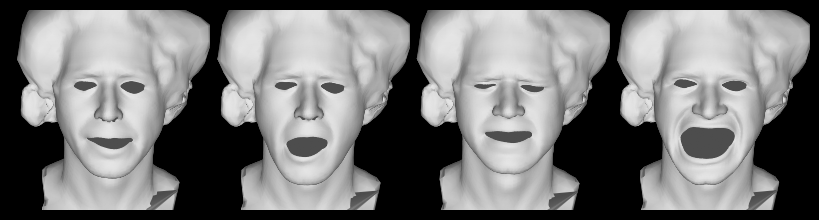

keypoint based deformation


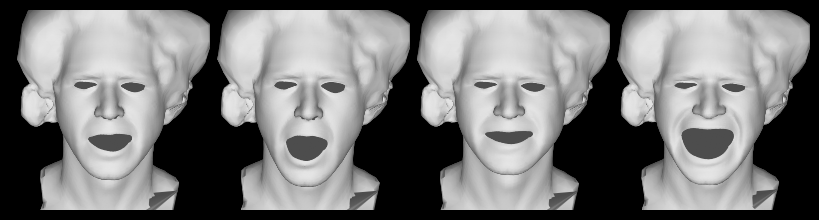

reconstruction


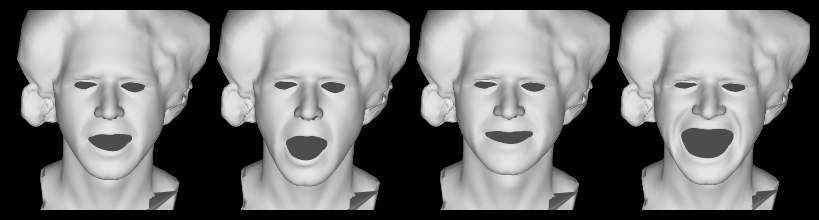

In [37]:
NNN=4
v_list=[
    deformed_v_th[NNN].detach().cpu().numpy(),
    deformed_v_th[NNN+1].detach().cpu().numpy(),
    deformed_v_th[NNN+2].detach().cpu().numpy(),
    deformed_v_th[NNN+3].detach().cpu().numpy(),
]

v_list2=[
    recon_deformed[NNN].detach().cpu().numpy(),
    recon_deformed[NNN+1].detach().cpu().numpy(),
    recon_deformed[NNN+2].detach().cpu().numpy(),
    recon_deformed[NNN+3].detach().cpu().numpy(),
]

v_list3=[
    recon_deformed_v_th[NNN].detach().cpu().numpy(),
    recon_deformed_v_th[NNN+1].detach().cpu().numpy(),
    recon_deformed_v_th[NNN+2].detach().cpu().numpy(),
    recon_deformed_v_th[NNN+3].detach().cpu().numpy(),
]
print('GT')
vis_simple(v_list, [faces]*len(v_list), SIZE=2)
print('keypoint based deformation')
vis_simple(v_list2, [faces]*len(v_list2), SIZE=2)
print('reconstruction')
vis_simple(v_list3, [faces]*len(v_list3), SIZE=2)

torch.Size([5223]) tensor([1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000], device='cuda:0',
       grad_fn=<SumBackward1>)


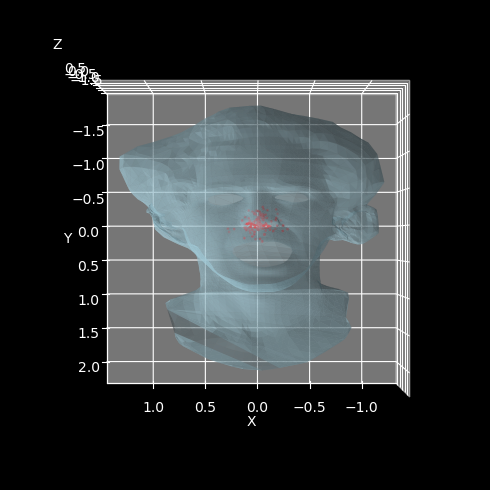

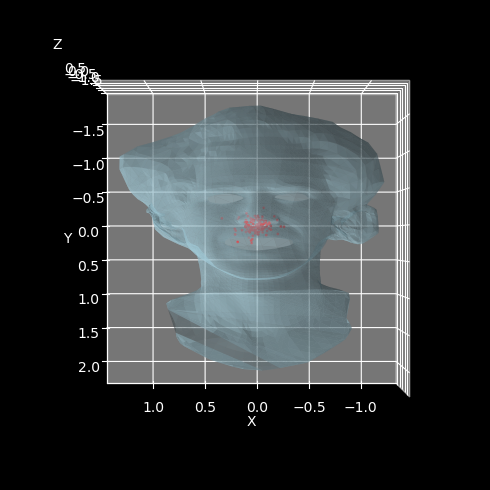

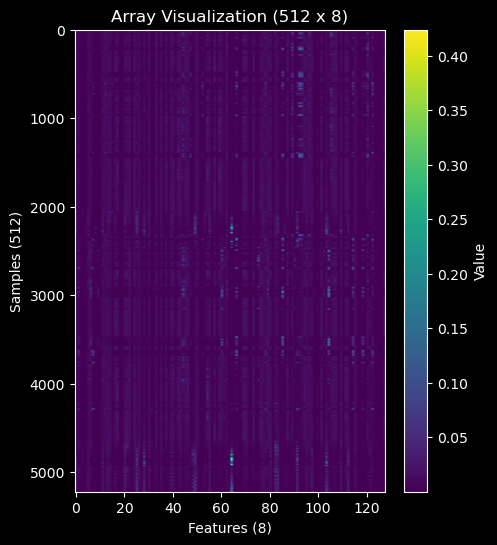

In [36]:
NNN=5
# print(key_weight[0].sum(0).shape, key_weight[0].sum(0))
print(key_weight[0].sum(1).shape, key_weight[0].sum(1))
draw_mesh_and_key_v(recon_deformed[NNN], key_d[NNN], faces)
draw_mesh_and_key_v(recon_deformed[NNN+1], key_d[NNN+1], faces)
draw_key_weight(key_weight[0])

# test 7

000, 9.787585e-01:   0%|          | 0/50000 [00:00<?, ?it/s]

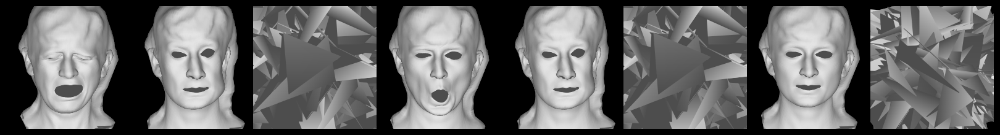

5000, 1.922989e-03:  10%|█         | 5000/50000 [08:49<2:03:23,  6.08it/s]

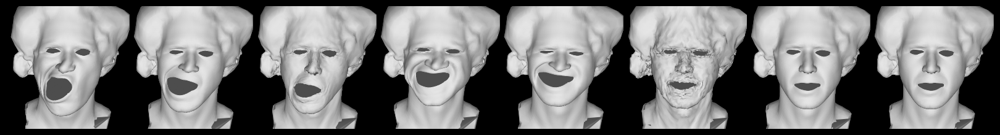

10000, 6.872882e-04:  20%|██        | 10000/50000 [23:14<1:54:12,  5.84it/s]

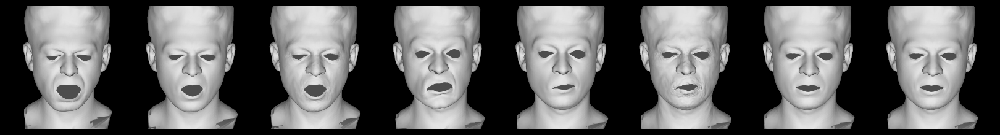

15000, 6.365414e-04:  30%|███       | 15000/50000 [37:47<1:49:48,  5.31it/s]

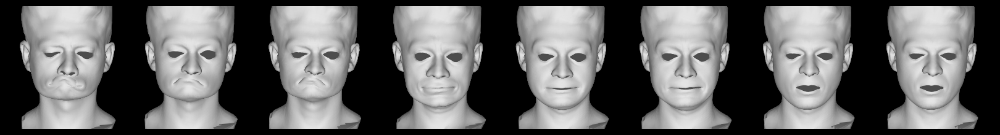

16949, 6.605631e-04:  34%|███▍      | 16950/50000 [43:27<1:32:44,  5.94it/s]

In [ ]:
from utils.exp_utils import Model, Model_mk2_1

N = template_v.shape[0]
M = 512
device = 'cuda:0'
max_influences=16
B = 16
HB = B//2
tau=0.05
L = 256

def get_rand_pca_data():
    rand_number = np.random.rand()
    mode=0
    if rand_number < 0.3:
        pca1,pca2 = pca_holder1, pca_holder2
        mode=1
    elif rand_number >= 0.3 and rand_number < 0.6:
        pca1,pca2 = pca_holder2, pca_holder3
        mode=2
    else:
        pca1,pca2 = pca_holder3, pca_holder1
        mode=3
    
    z1 = np.random.randn(HB, pca1.n_components_) * np.sqrt(pca1.explained_variance_) * 2.0
    z = np.concatenate((z1,z1),axis=0)
    z_th = torch.tensor(z).float().to(device)
    
    delta_v = np.einsum('bc,cnk->bnk', z, pca1.components_.reshape(pca1.n_components_,-1,3))
    # delta_v_th = torch.tensor(delta_v).float().to(device)

    _v = np.concatenate((
        pca1.mean_.reshape(1, -1, 3).repeat(HB,0),
        pca2.mean_.reshape(1, -1, 3).repeat(HB,0)
    ), axis=0)
    deformed_v = delta_v + _v
    deformed_v_th = torch.tensor(deformed_v).float().to(device)
    
    return z_th, deformed_v_th, mode

    
template_v1 = pca_holder1.mean_.reshape(-1, 3)
template_v2 = pca_holder2.mean_.reshape(-1, 3)
template_v3 = pca_holder3.mean_.reshape(-1, 3)

lap1 = igl.cotmatrix(template_v1, faces)
lap1_th = torch.tensor(lap1.todense()).float().to_sparse().to(device)

lap2 = igl.cotmatrix(template_v2, faces)
lap2_th = torch.tensor(lap2.todense()).float().to_sparse().to(device)

lap3 = igl.cotmatrix(template_v3, faces)
lap3_th = torch.tensor(lap3.todense()).float().to_sparse().to(device)

template_v1_th = torch.tensor(template_v1).float().to(device)
template_v2_th = torch.tensor(template_v2).float().to(device)
template_v3_th = torch.tensor(template_v3).float().to(device)

template_diff1_th = lap1_th @ template_v1_th
template_diff2_th = lap2_th @ template_v2_th
template_diff3_th = lap3_th @ template_v3_th

t_v12 = torch.cat([template_v1_th[None]]*HB+[template_v2_th[None]]*HB,dim=0)
t_v23 = torch.cat([template_v2_th[None]]*HB+[template_v3_th[None]]*HB,dim=0)
t_v31 = torch.cat([template_v3_th[None]]*HB+[template_v1_th[None]]*HB,dim=0)
t_v11 = template_v1_th[None].repeat(B,1,1)

# t_v12 = torch.cat([template_v1_th[None],template_v2_th[None]],dim=0)
# t_v23 = torch.cat([template_v2_th[None],template_v3_th[None]],dim=0)
# t_v31 = torch.cat([template_v3_th[None],template_v1_th[None]],dim=0)
# t_v11 = torch.cat([template_v1_th[None],template_v1_th[None]],dim=0)


# t_diff12 = torch.cat([template_diff1_th[None],template_diff2_th[None]],dim=0)
# t_diff23 = torch.cat([template_diff2_th[None],template_diff3_th[None]],dim=0)
# t_diff13 = torch.cat([template_diff1_th[None],template_diff3_th[None]],dim=0)

set_seed(42)
num_layers=4

key_weight_model = Model(
    in_dim=3, out_dim=M, 
    # use_softmax=True
    #use_relu=True
    use_least_N=True
).to(device)

exp_z_model = Model_mk2_1(
    in_dim=3, style_dim=L, out_dim=L,
    num_layers=num_layers, 
    use_style=True, out_type='global'
).to(device)
# exp_z_model = Model(3, L, out_type='global').to(device)

shape_model = Model(in_dim=3, out_dim=L, out_type='global').to(device)

# key_d_model = Model(L, M*3, out_type='global').to(device)
key_d_model = Model_mk2_1(
    in_dim=L, style_dim=L, out_dim=M*3, 
    num_layers=num_layers, 
    use_style=True, out_type='global'
).to(device)

recon_exp_model = Model(in_dim=L, out_dim=N*3, num_layers=num_layers, out_type='global').to(device)
recon_shp_model = Model(in_dim=L, out_dim=N*3, num_layers=num_layers, out_type='global').to(device)

zero_w = torch.zeros(N,M).to(device)


optimizer = torch.optim.AdamW([
    *key_d_model.parameters(),
    *key_weight_model.parameters(),
    *shape_model.parameters(),
    *exp_z_model.parameters(),
    *recon_exp_model.parameters(),
    *recon_shp_model.parameters(),
], lr=1e-3, betas=(0.9, 0.999))
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.9)

key_d_model.train()
key_weight_model.train()
shape_model.train()
exp_z_model.train()
recon_exp_model.train()
recon_shp_model.train()

pbar = tqdm(range(50_000))
for i in pbar:
    optimizer.zero_grad()
    
    ## data--------------- #
    exp_z_th, deformed_v_th, mode = get_rand_pca_data()
    if mode==1:
       t_v = t_v12
    elif mode==2:
       t_v = t_v23
    else:
       t_v = t_v31
    ## ------------------- #
    
    z_ID_B = shape_model(t_v) # (B, 1, L)
    recon_t_v_th = recon_shp_model(z_ID_B)
    recon_t_v_th = recon_t_v_th.reshape(B, N, 3)
    
    # z_ID_B = torch.cat([
    #     z_ID[0,None].repeat(HB,1,1),
    #     z_ID[1,None].repeat(HB,1,1),
    # ],dim=0) # (B, 1, L)
    
    key_weight = key_weight_model(t_v, N=256) # (B, N, M)
    # key_weight_B = torch.cat([
    #     key_weight[0,None].repeat(HB,1,1),
    #     key_weight[1,None].repeat(HB,1,1),
    # ],dim=0) # (B, N, M)

    
    exp_z = exp_z_model(deformed_v_th, z_ID_B) # (B, 1, L)
    #exp_z = exp_z_model(deformed_v_th) # (B, 1, L)
    
    # key_d = key_d_model(exp_z)
    key_d = key_d_model(exp_z, z_ID_B)
    key_d = key_d.reshape(B, M, 3)
    
    # recon_deformed_v_th = recon_model(exp_z, z_ID_B)
    recon_delta_v_th = recon_exp_model(exp_z)
    recon_delta_v_th = recon_delta_v_th.reshape(B, N, 3)
    recon_deformed_v_th = recon_delta_v_th + t_v

    # delta_v1_th = torch.einsum('nc,bci->bni',key_weight[0], key_d[:HB])
    # delta_v2_th = torch.einsum('nc,bci->bni',key_weight[1], key_d[HB:])
    # recon_deformed = torch.cat([
    #     delta_v1_th+t_v[0, None],
    #     delta_v2_th+t_v[1, None],
    # ],dim=0)
    
    delta_v_th = torch.einsum('bnc,bci->bni',key_weight,key_d)
    recon_deformed = delta_v_th + t_v
    
    loss = 0
    # loss = F.mse_loss(template_v_th, recon_template)
    loss += F.mse_loss(exp_z[:HB], exp_z[HB:]) * 0.5
    loss += F.mse_loss(deformed_v_th, recon_deformed)
    loss += F.mse_loss(deformed_v_th, recon_deformed_v_th)
    loss += F.mse_loss(t_v, recon_t_v_th)
    
    # make it harmonic
    #loss += F.mse_loss(zero_w, lap_th @ key_weight) #* 0.5
    # loss += F.mse_loss(
    #     lap_th @ deformed_v_th.permute(1,0,2).reshape(-1, B*3), 
    #     lap_th @ recon_deformed.permute(1,0,2).reshape(-1, B*3)
    # )
    
    loss.backward()
    optimizer.step()
    
    scheduler.step()
    
    pbar.set_description(f"{i:03d}, {loss.item():5e}")
    if i % 5000==0:
        #print(f"{i:03d}, {loss.item():5e}")        
        v_list=[
            deformed_v_th[0].detach().cpu().numpy(),
            recon_deformed[0].detach().cpu().numpy(),
            recon_deformed_v_th[0].detach().cpu().numpy(),
            deformed_v_th[1].detach().cpu().numpy(),
            recon_deformed[1].detach().cpu().numpy(),
            recon_deformed_v_th[1].detach().cpu().numpy(),
            t_v[0].detach().cpu().numpy(),
            recon_t_v_th[0].detach().cpu().numpy(),
        ]
        vis_simple(v_list, [faces]*len(v_list),SIZE=2)


In [7]:
def evaluation_mse6_1(
        key_d_model,
        key_weight_model,
        shape_model,
        exp_z_model,
        recon_exp_model,
        pca_holder, 
        B=8, M=128, num_sample=1000
    ):
    """
    Returns:
        evaluated results (recon_template, recon_deformed)
    """
    print(f'batch: {B}, num_sample: {num_sample}, iteration: {num_sample//B}')
    num_sample = num_sample//B
    
    losss = 0
    
    key_d_model.eval()
    key_weight_model.eval()
    shape_model.eval()
    exp_z_model.eval()
    recon_exp_model.eval()

    t_v_th = torch.tensor(pca_holder.mean_.reshape(-1,3)).float().to(device)
    t_v_B_th = t_v_th[None].repeat(B,1,1)
    
    set_seed(42)
    for i in tqdm(range(num_sample)):
        z = np.random.randn(B, pca_holder.n_components_) * np.sqrt(pca_holder.explained_variance_)
        deformed_v = pca_holder.inverse_transform(z).reshape(B,-1,3)
        #print(deformed_v.shape)
        z_th = torch.tensor(z).float().to(device)
        deformed_v_th = torch.tensor(deformed_v).float().to(device)

        with torch.no_grad():
            z_ID_B = shape_model(t_v_B_th) # (B, 1, L)
                        
            key_weight = key_weight_model(t_v_B_th) # (B, N, M)
            
            exp_z = exp_z_model(deformed_v_th, z_ID_B) # (B, 1, L)
            
            key_d = key_d_model(exp_z, z_ID_B).reshape(B, M, 3)
            
            recon_delta_v_th = recon_exp_model(exp_z).reshape(B, N, 3)
            recon_deformed_v_th = recon_delta_v_th + t_v_B_th
            
            delta_v_th = torch.einsum('bnc,bci->bni',key_weight,key_d)
            recon_deformed = delta_v_th + t_v_B_th
            
            loss = F.mse_loss(deformed_v_th, recon_deformed)
        losss +=loss.item()
        #print(loss.item())
    losss = losss / num_sample
    losss_txt = f"{losss:5e}"
    print(losss_txt)
    # write_data.py
    f = open("exp_CBD4_output.txt", 'w')
    f.write(losss_txt)
    f.close()

    return recon_deformed, recon_deformed_v_th, deformed_v_th, key_d

In [19]:
## trained sample
recon_deformed, recon_deformed_v_th, deformed_v_th, key_d = evaluation_mse6_1(
        key_d_model,
        key_weight_model,
        shape_model,
        exp_z_model,
        recon_exp_model,
        pca_holder, 
        B=B, M=M, num_sample=1000
    )

batch: 16, num_sample: 1000, iteration: 62


100%|██████████| 62/62 [00:05<00:00, 11.36it/s]

5.869773e-05


In [10]:
## unseen sample
recon_deformed, recon_deformed_v_th, deformed_v_th, key_d = evaluation_mse6_1(
        key_d_model,
        key_weight_model,
        shape_model,
        exp_z_model,
        recon_exp_model,
        pca_holder4, 
        B=B, M=M, num_sample=1000
    )

batch: 16, num_sample: 1000, iteration: 62


100%|██████████| 62/62 [00:05<00:00, 11.60it/s]


3.257220e-04


# test 8

000, 9.644140e-01:   0%|          | 0/20000 [00:00<?, ?it/s]

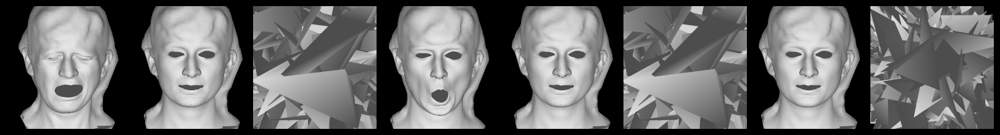

2000, 9.564074e-03:  10%|█         | 2000/20000 [05:40<49:28,  6.06it/s]

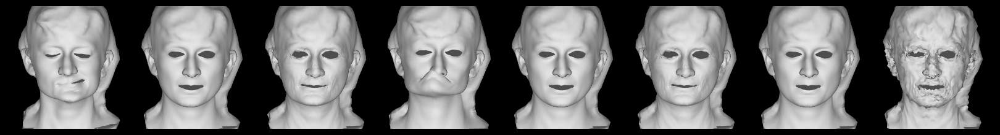

4000, 5.188840e-03:  20%|██        | 4000/20000 [11:22<47:36,  5.60it/s]  

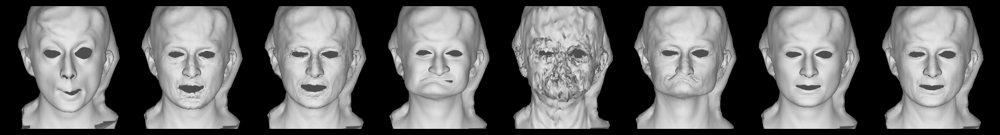

6000, 3.149603e-03:  30%|███       | 6000/20000 [17:02<41:50,  5.58it/s]  

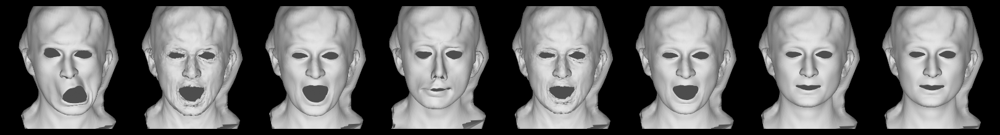

8000, 2.314158e-03:  40%|████      | 8000/20000 [22:44<34:35,  5.78it/s]  

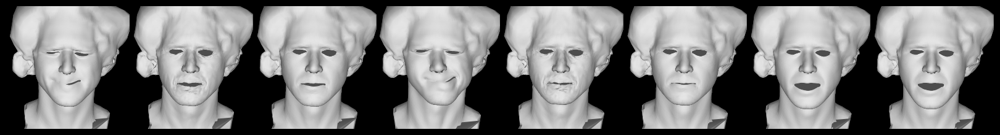

10000, 1.393652e-03:  50%|█████     | 10000/20000 [28:24<28:15,  5.90it/s]

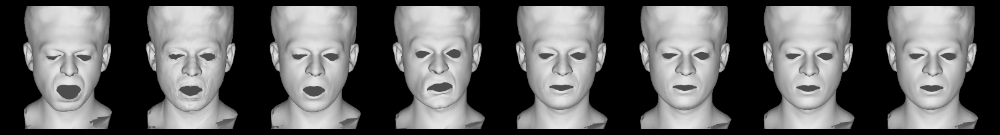

12000, 1.856947e-03:  60%|██████    | 12000/20000 [34:05<22:20,  5.97it/s]  

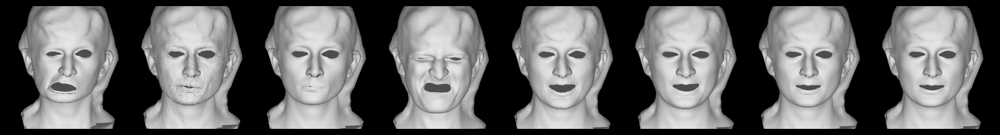

14000, 1.255856e-03:  70%|███████   | 14000/20000 [39:48<16:39,  6.00it/s]  

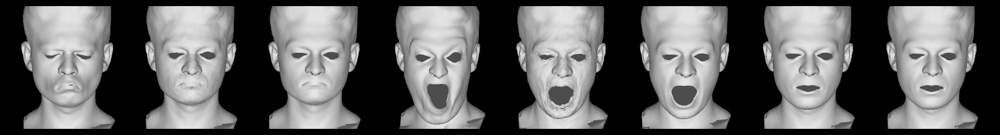

16000, 9.457445e-04:  80%|████████  | 16000/20000 [45:30<11:18,  5.89it/s]

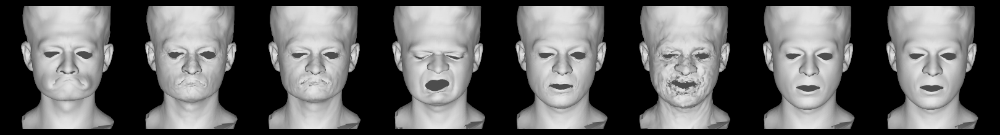

18000, 1.283720e-03:  90%|█████████ | 18000/20000 [51:11<05:40,  5.87it/s]

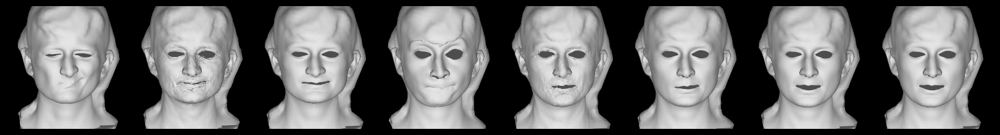

19999, 1.297088e-03: 100%|██████████| 20000/20000 [56:52<00:00,  5.86it/s]


In [19]:
from utils.exp_utils import Model, Model_mk2_1

N = template_v.shape[0]
K = 16
M = 256*K
device = 'cuda:0'
max_influences=16
B = 16

HB = B//2
tau=0.005
L=256

def get_rand_pca_data():
    rand_number = np.random.rand()
    mode=0
    if rand_number < 0.3:
        pca1,pca2 = pca_holder1, pca_holder2
        mode=1
    elif rand_number >= 0.3 and rand_number < 0.6:
        pca1,pca2 = pca_holder2, pca_holder3
        mode=2
    else:
        pca1,pca2 = pca_holder3, pca_holder1
        mode=3
    
    z1 = np.random.randn(HB, pca1.n_components_) * np.sqrt(pca1.explained_variance_) * 2.0
    z = np.concatenate((z1,z1),axis=0)
    z_th = torch.tensor(z).float().to(device)
    
    delta_v = np.einsum('bc,cnk->bnk', z, pca1.components_.reshape(pca1.n_components_,-1,3))
    # delta_v_th = torch.tensor(delta_v).float().to(device)

    _v = np.concatenate((
        pca1.mean_.reshape(1, -1, 3).repeat(HB,0),
        pca2.mean_.reshape(1, -1, 3).repeat(HB,0)
    ), axis=0)
    deformed_v = delta_v + _v
    deformed_v_th = torch.tensor(deformed_v).float().to(device)
    
    return z_th, deformed_v_th, mode

    
template_v1 = pca_holder1.mean_.reshape(-1, 3)
template_v2 = pca_holder2.mean_.reshape(-1, 3)
template_v3 = pca_holder3.mean_.reshape(-1, 3)

lap1 = igl.cotmatrix(template_v1, faces)
lap1_th = torch.tensor(lap1.todense()).float().to_sparse().to(device)

lap2 = igl.cotmatrix(template_v2, faces)
lap2_th = torch.tensor(lap2.todense()).float().to_sparse().to(device)

lap3 = igl.cotmatrix(template_v3, faces)
lap3_th = torch.tensor(lap3.todense()).float().to_sparse().to(device)

template_v1_th = torch.tensor(template_v1).float().to(device)
template_v2_th = torch.tensor(template_v2).float().to(device)
template_v3_th = torch.tensor(template_v3).float().to(device)

template_diff1_th = lap1_th @ template_v1_th
template_diff2_th = lap2_th @ template_v2_th
template_diff3_th = lap3_th @ template_v3_th

t_v12 = torch.cat([template_v1_th[None]]*HB+[template_v2_th[None]]*HB,dim=0)
t_v23 = torch.cat([template_v2_th[None]]*HB+[template_v3_th[None]]*HB,dim=0)
t_v31 = torch.cat([template_v3_th[None]]*HB+[template_v1_th[None]]*HB,dim=0)
t_v11 = template_v1_th[None].repeat(B,1,1)

# t_v12 = torch.cat([template_v1_th[None],template_v2_th[None]],dim=0)
# t_v23 = torch.cat([template_v2_th[None],template_v3_th[None]],dim=0)
# t_v31 = torch.cat([template_v3_th[None],template_v1_th[None]],dim=0)
# t_v11 = torch.cat([template_v1_th[None],template_v1_th[None]],dim=0)


# t_diff12 = torch.cat([template_diff1_th[None],template_diff2_th[None]],dim=0)
# t_diff23 = torch.cat([template_diff2_th[None],template_diff3_th[None]],dim=0)
# t_diff13 = torch.cat([template_diff1_th[None],template_diff3_th[None]],dim=0)

set_seed(42)

key_weight_model = Model(
    in_dim=3, out_dim=M, use_softmax=True,
    #use_K=True, K_dim=K,
).to(device)

exp_z_model = Model_mk2_1(
    in_dim=3, style_dim=L, out_dim=L, 
    use_style=True, out_type='global',
    # num_layers=6, 
).to(device)
# exp_z_model = Model(3, L, out_type='global').to(device)

shape_model = Model(
    in_dim=3, out_dim=L, out_type='global',
    # num_layers=6, 
).to(device)

# key_d_model = Model(L, M*3, out_type='global').to(device)
key_d_model = Model_mk2_1(
    in_dim=L, style_dim=L, out_dim=M*3, 
    use_style=True, out_type='global'
).to(device)

recon_exp_model = Model(in_dim=L, out_dim=N*3, num_layers=4, out_type='global').to(device)
recon_shp_model = Model(in_dim=L, out_dim=N*3, num_layers=4, out_type='global').to(device)


zero_w = torch.zeros(N,M).to(device)


optimizer = torch.optim.AdamW([
    *key_d_model.parameters(),
    *key_weight_model.parameters(),
    *shape_model.parameters(),
    *exp_z_model.parameters(),
    *recon_exp_model.parameters(),
    *recon_shp_model.parameters(),
], lr=1e-3, betas=(0.9, 0.999))
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.9)

key_d_model.train()
key_weight_model.train()
shape_model.train()
exp_z_model.train()
recon_exp_model.train()
recon_shp_model.train()

pbar = tqdm(range(20_000))
for i in pbar:
    optimizer.zero_grad()
    
    ## data--------------- #
    exp_z_th, deformed_v_th, mode = get_rand_pca_data()
    if mode==1:
        t_v = t_v12
        L1, L2 = lap1_th, lap2_th
    elif mode==2:
        t_v = t_v23
        L1, L2 = lap2_th, lap3_th
    else:
        t_v = t_v31
        L1, L2 = lap3_th, lap1_th
    ## ------------------- #
    
    z_ID_B = shape_model(t_v) # (B, 1, L)
    recon_t_v_th = recon_shp_model(z_ID_B)
    recon_t_v_th = recon_t_v_th.reshape(B, N, 3)
    
    # z_ID_B = torch.cat([
    #     z_ID[0,None].repeat(HB,1,1),
    #     z_ID[1,None].repeat(HB,1,1),
    # ],dim=0) # (B, 1, L)
    
    key_weight = key_weight_model(t_v) # (B, K, N, M//K)
    key_weight = key_weight.reshape(B, K, N, M//K)
    # key_weight_B = torch.cat([
    #     key_weight[0,None].repeat(HB,1,1),
    #     key_weight[1,None].repeat(HB,1,1),
    # ],dim=0) # (B, N, M)

    
    exp_z = exp_z_model(deformed_v_th, z_ID_B) # (B, 1, L)
    #exp_z = exp_z_model(deformed_v_th) # (B, 1, L)
    
    # key_d = key_d_model(exp_z)
    key_d = key_d_model(exp_z, z_ID_B)
    key_d = key_d.reshape(B, K, M//K, 3)
    
    # recon_deformed_v_th = recon_model(exp_z, z_ID_B)
    recon_delta_v_th = recon_exp_model(exp_z)
    recon_delta_v_th = recon_delta_v_th.reshape(B, N, 3)
    recon_deformed_v_th = recon_delta_v_th + t_v

    # delta_v1_th = torch.einsum('nc,bci->bni',key_weight[0], key_d[:HB])
    # delta_v2_th = torch.einsum('nc,bci->bni',key_weight[1], key_d[HB:])
    # recon_deformed = torch.cat([
    #     delta_v1_th+t_v[0, None],
    #     delta_v2_th+t_v[1, None],
    # ],dim=0)
    
    #delta_v_th = torch.einsum('bnc,bci->bni',key_weight,key_d)
    delta_v_th_K = torch.einsum('bknc,bkci->bkni',key_weight,key_d)
    #denom = key_weight.sum(-1).sum(1)
    delta_v_th = delta_v_th_K.mean(1)
    #delta_v_th = delta_v_th_K.sum(1) / denom[...,None]
    recon_deformed = delta_v_th + t_v
    
    loss = 0
    # loss = F.mse_loss(template_v_th, recon_template)
    loss += F.mse_loss(exp_z[:HB], exp_z[HB:]) * 0.5
    loss += F.mse_loss(deformed_v_th, recon_deformed)
    loss += F.mse_loss(deformed_v_th, recon_deformed_v_th)
    loss += F.mse_loss(t_v, recon_t_v_th)
    
    # make it harmonic
    #loss += F.mse_loss(zero_w, lap_th @ key_weight) #* 0.5
    # loss += F.mse_loss(
    #     L1 @ deformed_v_th[:HB].permute(1,0,2).reshape(-1, HB*3), 
    #     L1 @ recon_deformed[:HB].permute(1,0,2).reshape(-1, HB*3)
    # )
    # loss += F.mse_loss(
    #     L2 @ deformed_v_th[HB:].permute(1,0,2).reshape(-1, HB*3), 
    #     L2 @ recon_deformed[HB:].permute(1,0,2).reshape(-1, HB*3)
    # )
    
    loss.backward()
    optimizer.step()
    
    scheduler.step()
    
    pbar.set_description(f"{i:03d}, {loss.item():5e}")
    if i % 2000==0:
        #print(f"{i:03d}, {loss.item():5e}")        
        v_list=[
            deformed_v_th[0].detach().cpu().numpy(),
            recon_deformed[0].detach().cpu().numpy(),
            recon_deformed_v_th[0].detach().cpu().numpy(),
            deformed_v_th[1].detach().cpu().numpy(),
            recon_deformed[1].detach().cpu().numpy(),
            recon_deformed_v_th[1].detach().cpu().numpy(),
            t_v[0].detach().cpu().numpy(),
            recon_t_v_th[0].detach().cpu().numpy(),
        ]
        vis_simple(v_list, [faces]*len(v_list),SIZE=2)


# eval

In [27]:
def evaluation_mse7_1(
        key_d_model,
        key_weight_model,
        shape_model,
        exp_z_model,
        recon_exp_model,
        pca_holder, 
        B=8, M=128, num_sample=1000
    ):
    """
    Returns:
        evaluated results (recon_template, recon_deformed)
    """
    print(f'batch: {B}, num_sample: {num_sample}, iteration: {num_sample//B}')
    num_sample = num_sample//B
    
    losss = 0
    
    key_d_model.eval()
    key_weight_model.eval()
    shape_model.eval()
    exp_z_model.eval()
    recon_exp_model.eval()

    t_v_th = torch.tensor(pca_holder.mean_.reshape(-1,3)).float().to(device)
    t_v_B_th = t_v_th[None].repeat(B,1,1)
    
    set_seed(42)
    for i in tqdm(range(num_sample)):
        z = np.random.randn(B, pca_holder.n_components_) * np.sqrt(pca_holder.explained_variance_)
        deformed_v = pca_holder.inverse_transform(z).reshape(B,-1,3)
        #print(deformed_v.shape)
        z_th = torch.tensor(z).float().to(device)
        deformed_v_th = torch.tensor(deformed_v).float().to(device)

        with torch.no_grad():
            z_ID_B = shape_model(t_v_B_th) # (B, 1, L)
                        
            key_weight = key_weight_model(t_v_B_th) # (B, N, M)
            
            exp_z = exp_z_model(deformed_v_th, z_ID_B) # (B, 1, L)
            
            key_d = key_d_model(exp_z, z_ID_B).reshape(B, M, 3)
            
            recon_delta_v_th = recon_exp_model(exp_z).reshape(B, N, 3)
            recon_deformed_v_th = recon_delta_v_th + t_v_B_th
            
            delta_v_th = torch.einsum('bnc,bci->bni',key_weight,key_d)
            recon_deformed = delta_v_th + t_v_B_th
            
            loss = F.mse_loss(deformed_v_th, recon_deformed)
        losss +=loss.item()
        #print(loss.item())
    losss = losss / num_sample
    losss_txt = f"{losss:5e}"
    print(losss_txt)
    # write_data.py
    f = open("exp_CBD4_output.txt", 'w')
    f.write(losss_txt)
    f.close()
    return recon_deformed, recon_deformed_v_th, deformed_v_th, key_d

def evaluation_mse7_2(
        key_d_model,
        key_weight_model,
        shape_model,
        exp_z_model,
        recon_exp_model,
        pca_holder, 
        B=8, M=128, K=8,num_sample=1000
    ):
    """
    Returns:
        evaluated results (recon_template, recon_deformed)
    """
    print(f'batch: {B}, num_sample: {num_sample}, iteration: {num_sample//B}')
    num_sample = num_sample//B
    
    losss = 0
    
    key_d_model.eval()
    key_weight_model.eval()
    shape_model.eval()
    exp_z_model.eval()
    recon_exp_model.eval()

    t_v_th = torch.tensor(pca_holder.mean_.reshape(-1,3)).float().to(device)
    t_v_B_th = t_v_th[None].repeat(B,1,1)
    
    set_seed(42)
    for i in tqdm(range(num_sample)):
        z = np.random.randn(B, pca_holder.n_components_) * np.sqrt(pca_holder.explained_variance_)
        deformed_v = pca_holder.inverse_transform(z).reshape(B,-1,3)
        #print(deformed_v.shape)
        z_th = torch.tensor(z).float().to(device)
        deformed_v_th = torch.tensor(deformed_v).float().to(device)

        with torch.no_grad():
            z_ID_B = shape_model(t_v_B_th) # (B, 1, L)
                        
            key_weight = key_weight_model(t_v_B_th).reshape(B, K, N, M//K) # (B, K, N, M//K)
            
            exp_z = exp_z_model(deformed_v_th, z_ID_B) # (B, 1, L)
            
            key_d = key_d_model(exp_z, z_ID_B).reshape(B, K, M//K, 3) # (B, K, M//K, 3)
            
            recon_delta_v_th = recon_exp_model(exp_z).reshape(B, N, 3)
            recon_deformed_v_th = recon_delta_v_th + t_v_B_th
            
            delta_v_th_K = torch.einsum('bknc,bkci->bkni',key_weight,key_d)
            delta_v_th = delta_v_th_K.mean(1)
            #delta_v_th = delta_v_th_K.sum(1)
            # denom = key_weight.sum(-1).sum(1)
            # delta_v_th = delta_v_th_K.sum(1) / denom[...,None]
            recon_deformed = delta_v_th + t_v_B_th
            
            loss = F.mse_loss(deformed_v_th, recon_deformed)
        losss +=loss.item()
        #print(loss.item())
    losss = losss / num_sample
    losss_txt = f"{losss:5e}"
    print(losss_txt)
    # write_data.py
    f = open("exp_CBD4_output.txt", 'w')
    f.write(losss_txt)
    f.close()
    return recon_deformed, recon_deformed_v_th, deformed_v_th, key_d

In [29]:
recon_deformed, recon_deformed_v_th, deformed_v_th, key_d = evaluation_mse7_2(
        key_d_model,
        key_weight_model,
        shape_model,
        exp_z_model,
        recon_exp_model,
        pca_holder, 
        B=B, M=M, K=K, num_sample=1000
    )

batch: 16, num_sample: 1000, iteration: 62


100%|██████████| 62/62 [00:06<00:00,  9.21it/s]

1.425330e-04


In [ ]:
9.802829e-05 # B:  8 | M: 256 | L:256 | iter: 20_000 | tau=0.005 | num_layer=4
9.127664e-05 # B:  8 | M: 256 | L:512 | iter: 20_000 | tau=0.005 | num_layer=4
6.907172e-05 # B: 16 | M: 256 | L:512 | iter: 20_000 | tau=0.005 | num_layer=4
7.515670e-05 # B: 16 | M: 256 x 16 (multiple keyset) | L:512 | iter: 20_000 | tau=0.005 | num_layer=4 | mean | soft_max K 
7.469812e-05 # B: 16 | M: 256 x 16 (multiple keyset) | L:512 | iter: 20_000 | tau=0.005 | num_layer=4 | sum | softmax M 
7.675656e-05 # B: 16 | M: 128 x 32 (multiple keyset) | L:512 | iter: 20_000 | tau=0.005 | num_layer=4 | weighted sum | softmax M 
1.670413e-04 # B: 16 | M: 128 x 32 (multiple keyset) | L:512 | iter: 20_000 | tau=0.005 | num_layer=4 | weighted sum | softmax M  | laplacina reg

In [35]:
torch.cuda.empty_cache()

# Visualize

GT


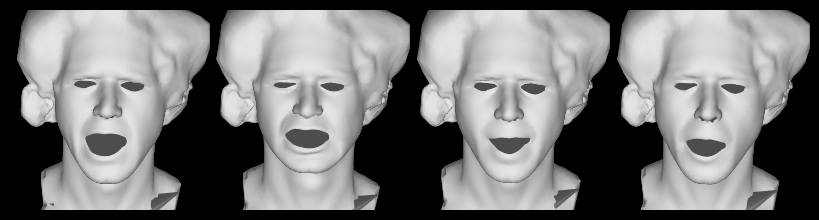

keypoint based deformation


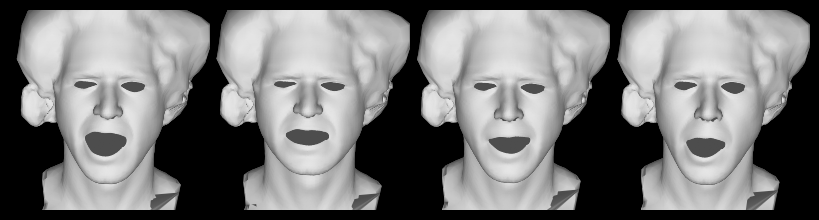

reconstruction


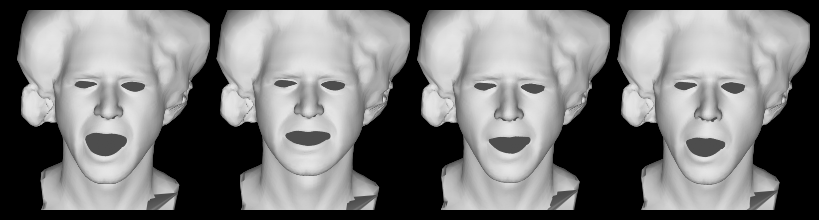

In [20]:
NNN=0
v_list=[
    deformed_v_th[NNN].detach().cpu().numpy(),
    deformed_v_th[NNN+1].detach().cpu().numpy(),
    deformed_v_th[NNN+2].detach().cpu().numpy(),
    deformed_v_th[NNN+3].detach().cpu().numpy(),
]

v_list2=[
    recon_deformed[NNN].detach().cpu().numpy(),
    recon_deformed[NNN+1].detach().cpu().numpy(),
    recon_deformed[NNN+2].detach().cpu().numpy(),
    recon_deformed[NNN+3].detach().cpu().numpy(),
]

v_list3=[
    recon_deformed_v_th[NNN].detach().cpu().numpy(),
    recon_deformed_v_th[NNN+1].detach().cpu().numpy(),
    recon_deformed_v_th[NNN+2].detach().cpu().numpy(),
    recon_deformed_v_th[NNN+3].detach().cpu().numpy(),
]
print('GT')
vis_simple(v_list, [faces]*len(v_list), SIZE=2)
print('keypoint based deformation')
vis_simple(v_list2, [faces]*len(v_list2), SIZE=2)
print('reconstruction')
vis_simple(v_list3, [faces]*len(v_list3), SIZE=2)

torch.Size([5223]) tensor([1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000], device='cuda:0',
       grad_fn=<SumBackward1>)


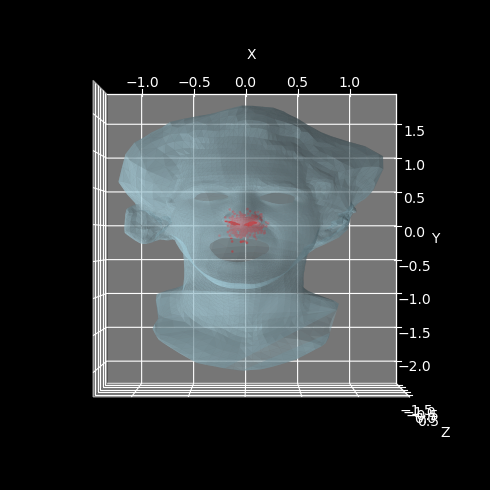

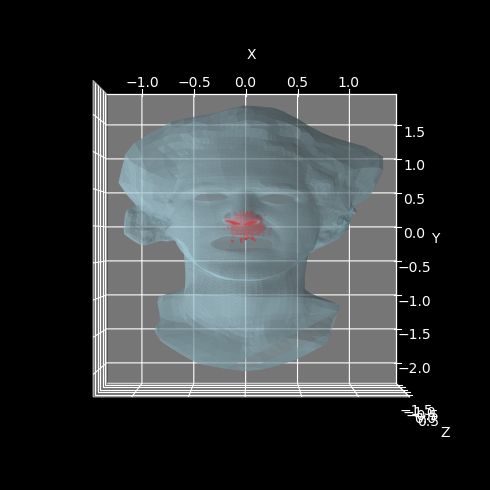

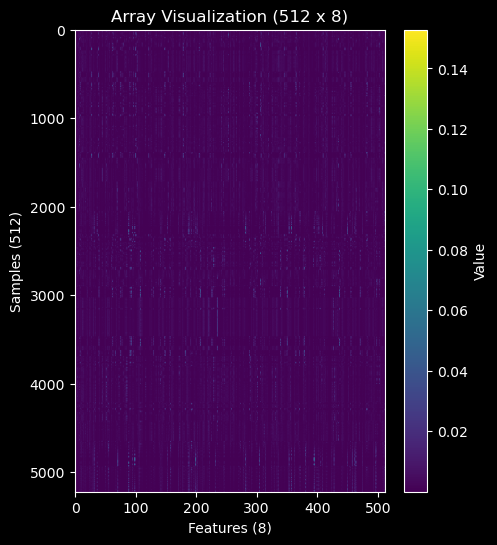

In [21]:
NNN=0 
# print(key_weight[0].sum(0).shape, key_weight[0].sum(0))
print(key_weight[0].sum(1).shape, key_weight[0].sum(1))
draw_mesh_and_key_v(recon_deformed[NNN], key_d[NNN], faces)
draw_mesh_and_key_v(recon_deformed[NNN+1], key_d[NNN+1], faces)
draw_key_weight(key_weight[0])

In [22]:
count_dim0 = torch.count_nonzero(key_weight[0], dim=1) # Count along columns
print(key_weight.shape)
print(key_weight[0].sum())
print(count_dim0)
print(count_dim0.max(),count_dim0.min())

torch.Size([16, 5223, 512])
tensor(5223., device='cuda:0', grad_fn=<SumBackward0>)
tensor([512, 512, 512,  ..., 512, 512, 512], device='cuda:0')
tensor(512, device='cuda:0') tensor(512, device='cuda:0')


In [16]:
(lap1_th @ key_weight[0]).sum()

tensor(-1.4143e-05, device='cuda:0', grad_fn=<SumBackward0>)

In [17]:
## key_weight smoothness
print((lap1_th @ key_weight[0]).sum())

## deformed vertex using Ours
print((lap1_th @ recon_deformed[NNN]).sum())

## deformed vertex using AE (per vertex displacement)
print((lap1_th @ recon_deformed_v_th[NNN]).sum())

tensor(-2.6226e-05, device='cuda:0')

tensor(1.9550e-05, device='cuda:0')

In [71]:
def vis_mesh(verts, faces, key_weight, SIZE=4, yrot=0):
    V = normalize_homogeneous(verts) 
    print(verts.min(0), verts.max(0))
    
    model = yrotate(yrot)
    view  = translate(0, 0, -3.5)
    proj  = perspective(55, 1, 1, 100)
    MVP   = proj @ view @ model
    V = V @ MVP.T
    V /= V[:, 3].reshape(-1, 1)

    
    VF = V[faces]
    T = VF[:, :, :2]
    Z = -VF[:, :, 2].mean(axis=1)
    Z = (Z - Z.min()) / (Z.max() - Z.min())
    C = plt.get_cmap("magma")(Z)
    I = np.argsort(Z)
    
    T, C = T[I, :], C[I, :]    
    
    fig = plt.figure(figsize=(SIZE, SIZE))
    ax = fig.add_axes([0, 0, 1, 1], xlim=[-1, 1], ylim=[-1, 1], aspect=1, frameon=False)
    collection = PolyCollection(T, closed=True, linewidth=0.1, facecolor=C, edgecolor="black")
    ax.add_collection(collection)
    plt.show()

In [81]:
from matplotlib.colors import Normalize

import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
import matplotlib.patches as mpatches

def vis_mesh_key_weight(
        verts, faces, key_weight, cage_idx,
        SIZE=4, yrot=0, cmap='magma', vmin=None, vmax=None, show_cbar=True
    ):
    """
    Args:
        verts: (N, 3)
        faces: (F, 3) int
        key_weight: (N, K)
        cage_idx: int
    """

    assert key_weight.shape[0] == verts.shape[0], \
        f"key_weight shape[0] ({key_weight.shape[0]}) != verts.shape[0] ({verts.shape[0]})"
    assert 0 <= cage_idx < key_weight.shape[1], \
        f"cage_idx {cage_idx} out of range [0, {key_weight.shape[1]-1}]"

    print("verts min/max:", verts.min(0), verts.max(0))

    Wv = key_weight[:, cage_idx]
    Wf = Wv[faces].mean(axis=1)

    if vmin is None: vmin = float(Wf.min())
    if vmax is None: vmax = float(Wf.max())
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap_fn = plt.get_cmap(cmap)

    V = normalize_homogeneous(verts)
    model = yrotate(yrot)
    view  = translate(0, 0, -3.5)
    proj  = perspective(55, 1.0, 1.0, 100.0)
    MVP   = proj @ view @ model
    V_clip = V @ MVP.T
    V_ndc  = V_clip[:, :3] / V_clip[:, 3:4]  # (N,3), -1~1

    VF = V_ndc[faces]
    T = VF[:, :, :2]
    Z = -VF[:, :, 2].mean(1)
    order = np.argsort(Z)

    T_sorted  = T[order]
    W_sorted  = Wf[order]

    C = cmap_fn(norm(W_sorted))  # (F,4)

    fig = plt.figure(figsize=(SIZE, SIZE))
    ax = fig.add_axes([0, 0, 1, 1], xlim=[-1, 1], ylim=[-1, 1], aspect=1, frameon=False)
    coll = PolyCollection(T_sorted, closed=True, linewidth=0.2, facecolor=C, edgecolor="black")
    ax.add_collection(coll)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)

    if show_cbar:
        # colorbar를 위한 ScalarMappable
        from matplotlib.cm import ScalarMappable
        sm = ScalarMappable(norm=norm, cmap=cmap_fn)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(f"key_weight[:, {cage_idx}]")

    plt.title(f"Cage vertex {cage_idx} weight")
    plt.show()

def vis_mesh_all_cage_weights(
    verts, faces, key_weight,
    cage_indices=None,          # 시각화할 케이지 인덱스 리스트 (None이면 전체)
    mode='argmax',              # 'argmax' | 'blend'
    SIZE=4, yrot=0,
    base_cmap='tab20',          # 범주형 팔레트(케이지별 색)
    show_legend=False
):
    """
    각 face를 'cage별 weight'로 색칠해서 한 번에 시각화.

    - mode='argmax': face에서 평균 weight가 가장 큰 cage의 색으로 칠함 (카테고리)
    - mode='blend' : face 색 = Σ_k (정규화된 weight_k * cage_k 색) (가산 혼합)

    Args:
        verts: (N, 3)
        faces: (F, 3) int
        key_weight: (N, K)  # mesh vertex x cage vertex
        cage_indices: list[int] or None
        base_cmap: matplotlib colormap name (범주형에 적합한 컬러맵 권장: 'tab20', 'tab20b', ...)
    """
    verts  = np.asarray(verts)
    faces  = np.asarray(faces, dtype=int)
    W_full = np.asarray(key_weight)
    N, K = W_full.shape
    assert verts.shape[0] == N, f"verts ({verts.shape[0]}) vs key_weight rows ({N}) mismatch"

    if cage_indices is None:
        cage_indices = list(range(K))
    else:
        # 유효성 체크
        cage_indices = list(cage_indices)
        assert all(0 <= i < K for i in cage_indices), "cage_indices out of range"

    M = len(cage_indices)  # 시각화할 케이지 수
    # 색 팔레트 준비
    cmap = plt.get_cmap(base_cmap, max(M, 3))  # 최소 3 보장
    if M <= cmap.N:
        base_colors = np.asarray([cmap(i) for i in range(M)])  # (M,4)
    else:
        # 케이지가 매우 많으면 넓은 컬러맵에서 균등 샘플
        cmap_wide = plt.get_cmap('gist_ncar')
        base_colors = np.asarray([cmap_wide(i/(M-1)) for i in range(M)])

    # (N, M) 선택 케이지 weight
    W_sel = W_full[:, cage_indices]  # (N, M)
    # face 평균 -> (F, M)
    Wf_all = W_sel[faces].mean(axis=1)

    # 투영
    V = normalize_homogeneous(verts)
    model = yrotate(yrot)
    view  = translate(0, 0, -3.5)
    proj  = perspective(55, 1.0, 1.0, 100.0)
    MVP   = proj @ view @ model
    V_clip = V @ MVP.T
    V_ndc  = V_clip[:, :3] / V_clip[:, 3:4]

    VF = V_ndc[faces]        # (F, 3, 3)
    T  = VF[:, :, :2]        # (F, 3, 2)
    Z  = -VF[:, :, 2].mean(1)
    order = np.argsort(Z)

    T_sorted = T[order]
    W_sorted = Wf_all[order]

    # face 색 만들기
    if mode == 'argmax':
        labels = np.argmax(W_sorted, axis=1)  # (F,)
        face_colors = base_colors[labels]     # (F,4)
    elif mode == 'blend':
        # 행 정규화 후 가중합 (RGB만 혼합, alpha=1)
        sum_row = W_sorted.sum(axis=1, keepdims=True) + 1e-12
        Wn = W_sorted / sum_row
        rgb = Wn @ base_colors[:, :3]    # (F,3)
        rgb = np.clip(rgb, 0, 1)
        alpha = np.ones((rgb.shape[0], 1))
        face_colors = np.concatenate([rgb, alpha], axis=1)  # (F,4)
    else:
        raise ValueError("mode must be 'argmax' or 'blend'")

    # 렌더
    fig = plt.figure(figsize=(SIZE, SIZE))
    ax = fig.add_axes([0, 0, 1, 1], xlim=[-1, 1], ylim=[-1, 1], aspect=1, frameon=False)
    coll = PolyCollection(T_sorted, closed=True, linewidth=0.2,
                          facecolor=face_colors, edgecolor="black")
    ax.add_collection(coll)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
    plt.title(f"All cage weights ({mode})")

    if show_legend:
        handles = []
        for i, ci in enumerate(cage_indices):
            handles.append(mpatches.Patch(color=base_colors[i], label=f"cage {ci}"))
        
        if len(handles) <= 12:
            ax.legend(handles=handles, loc='upper right', fontsize=8)
        else:
            ax.legend(handles=handles, bbox_to_anchor=(1.02, 1.0), loc='upper left',
                      borderaxespad=0., fontsize=7, ncol=1)

    plt.show()


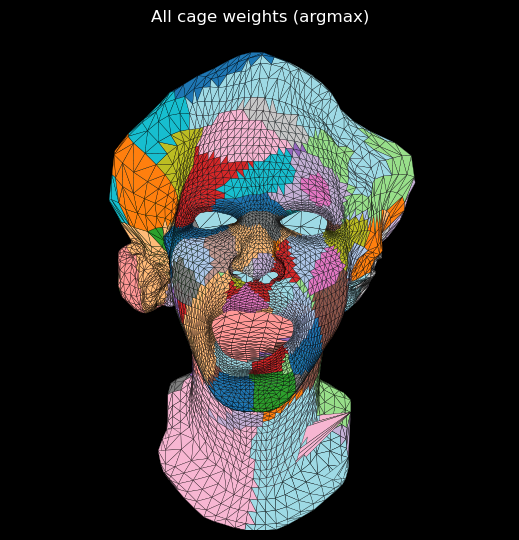

In [51]:
KW = key_weight[NNN].detach().cpu().numpy()
vis_mesh_all_cage_weights(recon_deformed[NNN].detach().cpu().numpy(), faces, KW, mode='argmax', SIZE=5, yrot=0)

torch.Size([5223, 512])
verts min/max: [-1.156346  -2.06007   -1.5979663] [1.2674296  1.6726743  0.74585015]


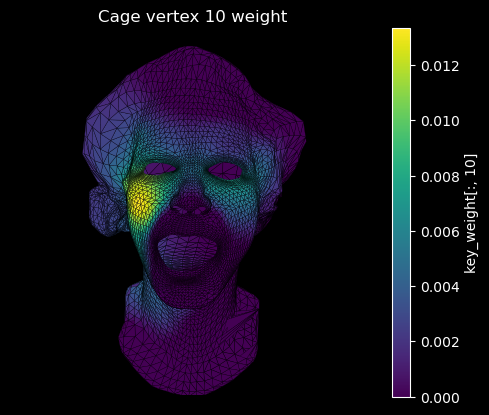

verts min/max: [-1.156346  -2.06007   -1.5979663] [1.2674296  1.6726743  0.74585015]


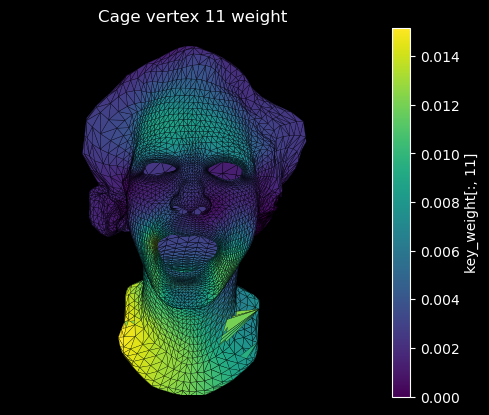

verts min/max: [-1.156346  -2.06007   -1.5979663] [1.2674296  1.6726743  0.74585015]


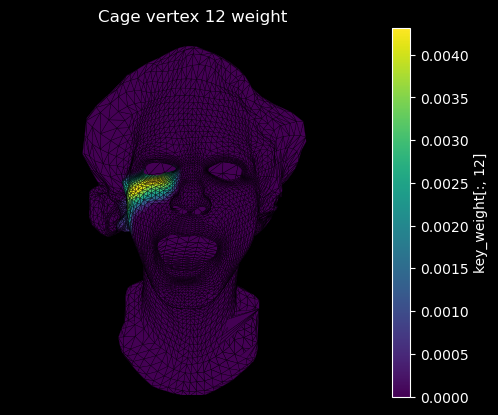

verts min/max: [-1.156346  -2.06007   -1.5979663] [1.2674296  1.6726743  0.74585015]


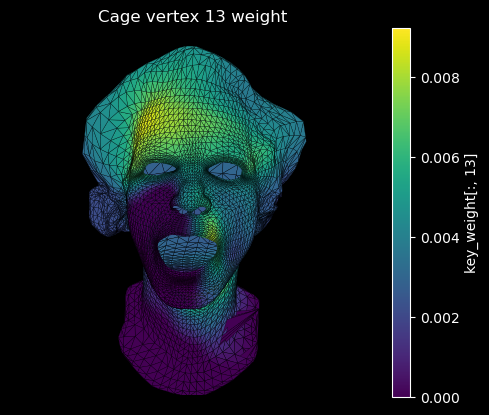

verts min/max: [-1.156346  -2.06007   -1.5979663] [1.2674296  1.6726743  0.74585015]


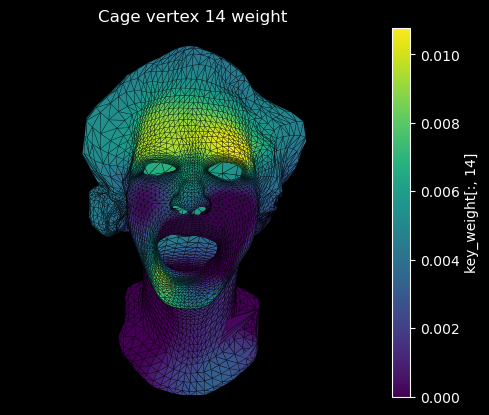

In [88]:
# recon_deformed[NNN], key_d[NNN], faces
print(key_weight[NNN].shape)
for NC in range(10,15):
    vis_mesh_key_weight(recon_deformed[NNN].detach().cpu().numpy(), faces, key_weight[NNN].detach().cpu().numpy(), cage_idx=NC, SIZE=4, yrot=0, cmap='viridis')

verts min/max: [-1.15638869 -2.06067469 -1.59787963] [1.268583   1.68536989 0.75121842]


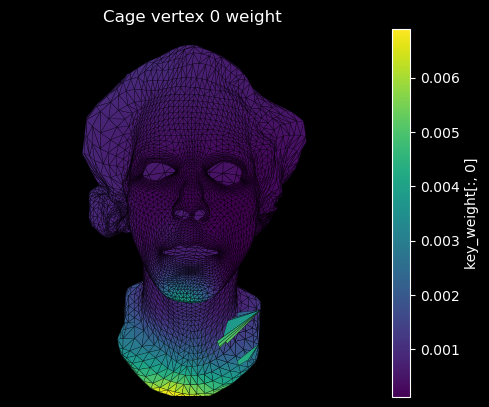

In [195]:
asd = key_weight[NNN].detach().cpu().numpy() @ key_d[NNN].detach().cpu().numpy() + pca_holder1.mean_.reshape(-1,3)

asd - pca_holder1.mean_.reshape(-1,3) = key_weight[NNN].detach().cpu().numpy() @ key_d[NNN].detach().cpu().numpy()
# asd.shape

vis_mesh_key_weight(asd, faces, key_weight[NNN].detach().cpu().numpy(), cage_idx=NC, SIZE=4, yrot=0, cmap='viridis')

In [239]:
deformed_v_th[NNN].shape
key_d[NNN].shape
t_v_th = torch.tensor(pca_holder1.mean_.reshape(-1,3)).float().to(device)
print(t_v_th.shape)

CCC = key_d[NNN].detach().cpu().numpy()
# CCC = deformed_v_th[NNN,[0,1,2,3,4,5,6,7]].detach().cpu().numpy()
# CCC = np.eye()
# CCC /= np.linalg.norm(CCC, axis=1,keepdims=True)
VVV = (deformed_v_th[NNN]-t_v_th).detach().cpu().numpy()
# VVV /= np.linalg.norm(VVV, axis=1,keepdims=True)

#_weight = VVV @ CCC.T # @ (np.linalg.pinv(CCC @ CCC.T))
MMM = CCC @ CCC.T
print(MMM.shape)
_weight = (VVV @ CCC.T) @ MMM.T  @ (np.linalg.pinv(MMM @ MMM.T))



# VVV_noise = (deformed_v_th[NNN]-t_v_th).detach().cpu().numpy() + np.random.rand(5223, 3)*1e-2
# VVV_noise /= np.linalg.norm(VVV_noise, axis=1,keepdims=True)
# _weight_noise = VVV_noise @ CCC.T # @ (np.linalg.pinv(CCC @ CCC.T))

# _weight = _weight / np.linalg.norm(_weight, axis=1,keepdims=True)
# _weight = _weight-_weight.min(1,keepdims=True) / _weight.max(1,keepdims=True)-_weight.min(1,keepdims=True)
# _weight = np.clip(_weight,a_min=0,a_max=_weight.max())
print(_weight.shape)


torch.Size([5223, 3])
(256, 256)
(5223, 256)


verts min/max: [-1.1568522 -2.0589166 -1.6001712] [1.2689111  1.6873691  0.74913853]


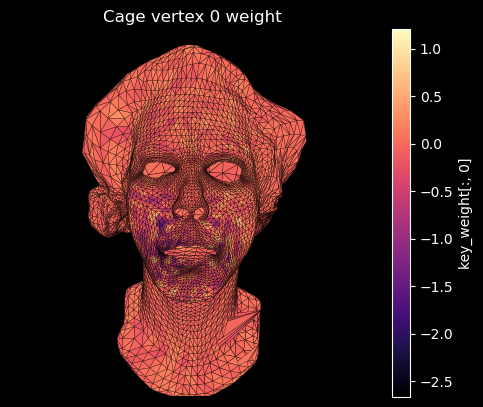

In [240]:
vis_mesh_key_weight(recon_deformed_v_th[NNN].detach().cpu().numpy(), faces, _weight, cage_idx=NC, SIZE=4, yrot=0)#, cmap='viridis')

verts min/max: [-1.1568522 -2.0589166 -1.6001712] [1.2689111  1.6873691  0.74913853]


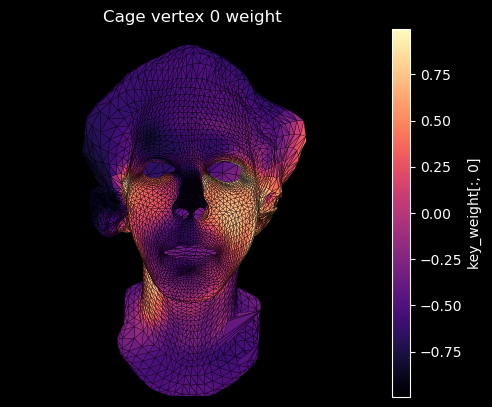

verts min/max: [-1.1568522 -2.0589166 -1.6001712] [1.2689111  1.6873691  0.74913853]


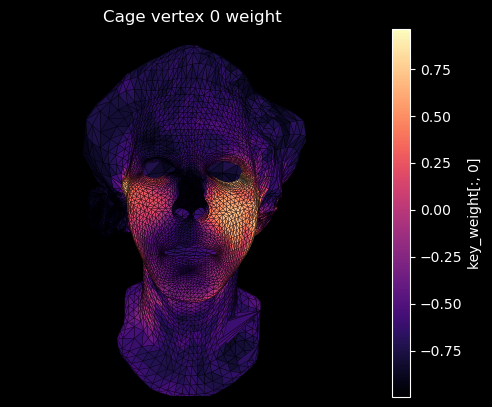

In [233]:

NC=0
vis_mesh_key_weight(recon_deformed_v_th[NNN].detach().cpu().numpy(), faces, _weight, cage_idx=NC, SIZE=4, yrot=0)#, cmap='viridis')
vis_mesh_key_weight(recon_deformed_v_th[NNN].detach().cpu().numpy(), faces, _weight_noise, cage_idx=NC, SIZE=4, yrot=0)#, cmap='viridis')

(256, 256)
(5223, 256)
verts min/max: [-1.1555145 -2.0585468 -1.5979446] [1.2695947 1.6856039 0.7501099]


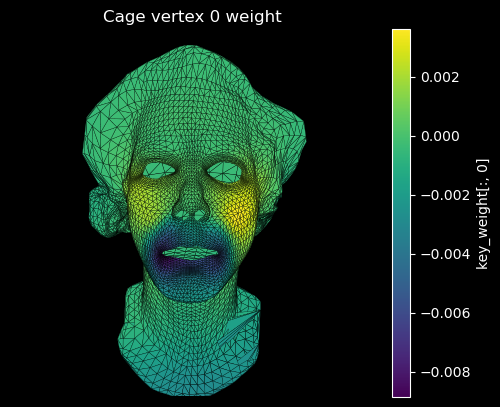

In [215]:

CCC = key_d[NNN].detach().cpu().numpy()
# CCC = CCC / np.linalg.norm(CCC,axis=1,keepdims=True)
VVV = (recon_deformed[NNN]-t_v_th).detach().cpu().numpy()
# VVV = VVV / np.linalg.norm(VVV,axis=1,keepdims=True)


print((CCC @ CCC.T).shape)
_weight = VVV @ CCC.T #@ (np.linalg.inv(CCC @ CCC.T))
# _weight = np.clip(_weight,a_min=0,a_max=_weight.max())
# _weight = _weight / np.linalg.norm(_weight, axis=1,keepdims=True)
# _weight = _weight-_weight.min(1,keepdims=True) / _weight.max(1,keepdims=True)-_weight.min(1,keepdims=True)
print(_weight.shape)

vis_mesh_key_weight(recon_deformed[NNN].detach().cpu().numpy(), faces, _weight, cage_idx=NC, SIZE=4, yrot=0, cmap='viridis')

In [177]:
_weight

array([[ 0.21875   ,  1.25      ,  0.        , ...,  0.5       ,
         0.125     ,  0.09375   ],
       [ 0.        , -3.        ,  0.        , ..., -1.        ,
         0.        , -0.125     ],
       [-9.        ,  0.        , -2.375     , ...,  2.        ,
         3.5       ,  0.75      ],
       ...,
       [-0.3551646 ,  1.1757557 , -0.85328615, ...,  0.08901097,
         3.2134137 , -0.2897603 ],
       [-0.27996856, -2.8975492 , -0.00940583, ..., -1.2540332 ,
        -2.2885795 , -0.03677003],
       [-0.17830911, -0.32322732,  0.2013782 , ..., -2.6039515 ,
         1.7894768 ,  0.2240496 ]], dtype=float32)

In [190]:
A = key_d[NNN] @ key_d[NNN].permute(1,0)
B = (deformed_v_th[NNN]-t_v_th) @ key_d[NNN].permute(1,0)

W = torch.linalg.solve(A, B, left=False)

In [191]:
W.shape

torch.Size([5223, 256])

verts min/max: [-1.159115  -2.061925  -1.6009154] [1.2694484  1.681483   0.75031686]


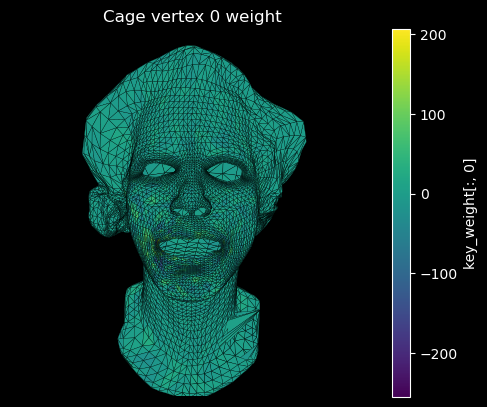

In [192]:

vis_mesh_key_weight(t_v_th.detach().cpu().numpy(), faces, W.detach().cpu().numpy(), cage_idx=NC, SIZE=4, yrot=0, cmap='viridis')

In [174]:
key_weight[0]

tensor([[6.6833e-04, 4.1032e-04, 5.3902e-04,  ..., 7.2395e-03, 2.9670e-03,
         3.4098e-04],
        [7.2761e-04, 2.4179e-04, 2.9559e-04,  ..., 5.6356e-03, 1.2810e-02,
         3.4177e-04],
        [1.9266e-03, 7.8335e-04, 3.4143e-04,  ..., 1.8809e-03, 2.3525e-03,
         7.8403e-04],
        ...,
        [8.1800e-04, 4.9125e-05, 4.8726e-05,  ..., 3.2918e-03, 2.2256e-03,
         3.1294e-04],
        [8.8619e-04, 5.4511e-05, 4.5751e-05,  ..., 3.2388e-03, 1.9671e-03,
         3.2978e-04],
        [9.3844e-04, 6.2342e-05, 4.6202e-05,  ..., 3.2779e-03, 1.7455e-03,
         3.4247e-04]], device='cuda:0', grad_fn=<SelectBackward0>)

In [209]:
qwe= torch.rand(8,5)
wer= torch.rand(5,3)

zxc = qwe @ wer # 8,3
# print(zxc)

### zxc = qwe @ wer
### zxc @ wer.T = qwe @ (wer @ wer.T)
### zxc @ wer.T @ inv(wer @ wer.T) = qwe
A = wer @ wer.T
B = zxc @ wer.T

qWe = torch.linalg.solve(A, B, left=False)

print(qWe)
print(qwe)
torch.allclose(qwe, qWe)

tensor([[ 0.1346,  1.2667,  0.1682,  0.7062,  0.7938],
        [ 0.1336,  0.0418, -0.6547,  2.4021,  0.5979],
        [ 0.4939,  2.6983,  1.9508, -2.3196,  1.3196],
        [ 0.2327, -0.0945,  0.1747,  0.1946, -0.0696],
        [-0.2025,  0.6733, -0.4061,  1.0464,  1.4536],
        [ 0.3374,  0.4050,  0.7928,  0.2010,  0.2990],
        [ 1.9459, -2.3847,  1.2860,  1.2784, -1.2784],
        [ 0.7231,  0.3301,  1.0691, -0.1701,  0.6701]])
tensor([[0.3882, 0.7410, 0.3636, 0.7341, 0.3908],
        [0.1609, 0.7035, 0.5767, 0.7229, 0.9967],
        [0.8414, 0.9740, 0.5268, 0.0699, 0.1492],
        [0.1894, 0.0594, 0.2494, 0.0397, 0.0387],
        [0.2012, 0.0071, 0.1931, 0.6907, 0.9170],
        [0.3513, 0.3546, 0.7670, 0.2533, 0.2636],
        [0.8081, 0.0643, 0.5611, 0.9417, 0.5857],
        [0.6360, 0.2088, 0.4931, 0.5275, 0.6227]])


False

In [212]:
import torch
qwe = torch.rand(8,5)
wer = torch.rand(5,3)

zxc = qwe @ wer

# 특이성 확인
A = wer @ wer.T
print('rank(A)=', torch.linalg.matrix_rank(A))   # 보통 3

# 최소노름 해
qW = zxc @ torch.linalg.pinv(wer)
print('reproj ok?:', torch.allclose(qW @ wer, zxc, atol=1e-6))

# 원본과 같아야 하는 조건이 아님 → 보통 False
print('equals original?:', torch.allclose(qW, qwe, atol=1e-6))

# qwe를 wer의 부분공간으로 투영하면 일치
P = wer @ torch.linalg.pinv(wer)
qwe_proj = qwe @ P
print('proj equals?:', torch.allclose(qW, qwe_proj, atol=1e-6))


rank(A)= tensor(3)
reproj ok?: True
equals original?: False
proj equals?: True


In [207]:
qwe= torch.rand(8,5)
wer=torch.rand(5,3)

zxc_T = wer.T @ qwe.T  # 8,3


### zxc = qwe @ wer
### zxc @ wer.T = qwe @ (wer @ wer.T)
### zxc @ wer.T @ inv(wer @ wer.T) = qwe
A = wer @ wer.T
B = wer @ zxc_T

qW = torch.linalg.solve(A, B)

print(qW.T)
print(qwe)
torch.allclose(qwe, qW.T)

tensor([[ 2.9146, -2.5145,  0.7215,  1.0095,  0.4567],
        [ 2.5734, -2.5167,  1.2297,  0.2125,  0.3948],
        [ 0.3108, -0.6071, -0.1609,  2.1929, -0.8638],
        [ 0.5969,  0.3081,  0.9406,  0.7050,  0.0792],
        [ 0.9220,  0.1992,  0.7666, -0.1722,  0.9189],
        [-0.4847,  0.9010,  0.1181,  1.2321,  0.8060],
        [ 1.4167,  0.7108,  1.0772, -0.6007,  1.1348],
        [ 1.3961, -0.7457,  0.1819,  0.6383,  0.2177]])
tensor([[0.3489, 0.8636, 0.4870, 0.8903, 0.9807],
        [0.2564, 0.1352, 0.9012, 0.8918, 0.1182],
        [0.4613, 0.0069, 0.0907, 0.5966, 0.6330],
        [0.6060, 0.3639, 0.9613, 0.5715, 0.2050],
        [0.4717, 0.6201, 0.6751, 0.1465, 0.6874],
        [0.2446, 0.0845, 0.2269, 0.9822, 0.9274],
        [0.9477, 0.7935, 0.8777, 0.4331, 0.2249],
        [0.7498, 0.2409, 0.1626, 0.3403, 0.6049]])


False